# Lecturer Publication Graph Mining Temporal Link Prediction And Expert Retrieval

## Environment Setup

In [1]:
!pip install -q sentence-transformers umap-learn hdbscan torch-geometric networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.8 MB/s eta 0:00:00


In [2]:
import os
import json
import math
import random
import zipfile
import itertools
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, RGCNConv, VGAE
from torch_geometric.nn.kge import RotatE, ComplEx

import umap
import hdbscan
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import MinMaxScaler

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device selected", DEVICE)

OUTPUT_ROOT = "output"
OUTPUT_VIZ = os.path.join(OUTPUT_ROOT, "viz")
OUTPUT_MODELS = os.path.join(OUTPUT_ROOT, "models")

for folder in [OUTPUT_ROOT, OUTPUT_VIZ, OUTPUT_MODELS]:
    os.makedirs(folder, exist_ok=True)
    print("folder ready", folder)

ARTIFACT_MANIFEST = []


def register_artifact(path, description):
    ARTIFACT_MANIFEST.append({"path": path, "description": description})
    print("artifact registered", path, description)

device selected cuda
folder ready output
folder ready output/viz
folder ready output/models


## Data Loading

In [3]:
RAW_CSV_PATH = "merged-clean-fixed_2905.csv"

raw_df = pd.read_csv(RAW_CSV_PATH, sep="|")
print("raw shape", raw_df.shape)
print("raw columns", list(raw_df.columns))

raw shape (6160, 10)
raw columns ['Title', 'Year', 'Journal', 'Keywords', 'Document Type', 'DOI', 'Unesa Authors', 'IEEE-Keywords', '_source', 'Unesa Names']


In [4]:
dtype_summary = raw_df.dtypes.astype(str).rename("dtype").reset_index()
dtype_summary.columns = ["column", "dtype"]

null_summary = raw_df.isnull().sum().rename("null_count").reset_index()
null_summary.columns = ["column", "null_count"]
null_summary["null_ratio"] = null_summary["null_count"] / len(raw_df)

shape_summary = pd.DataFrame(
    {"metric": ["n_rows", "n_columns"], "value": [raw_df.shape[0], raw_df.shape[1]]}
)

shape_summary_path = os.path.join(OUTPUT_ROOT, "raw_shape_summary.csv")
dtype_summary_path = os.path.join(OUTPUT_ROOT, "raw_dtype_summary.csv")
null_summary_path = os.path.join(OUTPUT_ROOT, "raw_null_summary.csv")

shape_summary.to_csv(shape_summary_path, index=False)
dtype_summary.to_csv(dtype_summary_path, index=False)
null_summary.to_csv(null_summary_path, index=False)

register_artifact(shape_summary_path, "raw dataframe shape summary")
register_artifact(dtype_summary_path, "raw dataframe dtype summary per column")
register_artifact(null_summary_path, "raw dataframe null value summary per column")

print(f"\n{shape_summary.to_string(index=False)}")
print(f"\n{null_summary.to_string(index=False)}")

artifact registered output/raw_shape_summary.csv raw dataframe shape summary
artifact registered output/raw_dtype_summary.csv raw dataframe dtype summary per column
artifact registered output/raw_null_summary.csv raw dataframe null value summary per column

   metric  value
   n_rows   6160
n_columns     10

       column  null_count  null_ratio
        Title           0    0.000000
         Year           0    0.000000
      Journal           0    0.000000
     Keywords         183    0.029708
Document Type           0    0.000000
          DOI        5087    0.825812
Unesa Authors           0    0.000000
IEEE-Keywords           0    0.000000
      _source           0    0.000000
  Unesa Names           0    0.000000


## Exploratory Data Analysis

### Publication Volume And Category Distributions

year range observed 1990 to 2027
Document Type
journal article     5623
conference paper     516
book chapter          10
review                 8
dissertation           2
data paper             1
Name: count, dtype: int64
_source
google_scholar    5313
scopus             847
Name: count, dtype: int64
n_authors
1    4486
2    1164
3     363
4     104
5      35
6       8
Name: count, dtype: int64


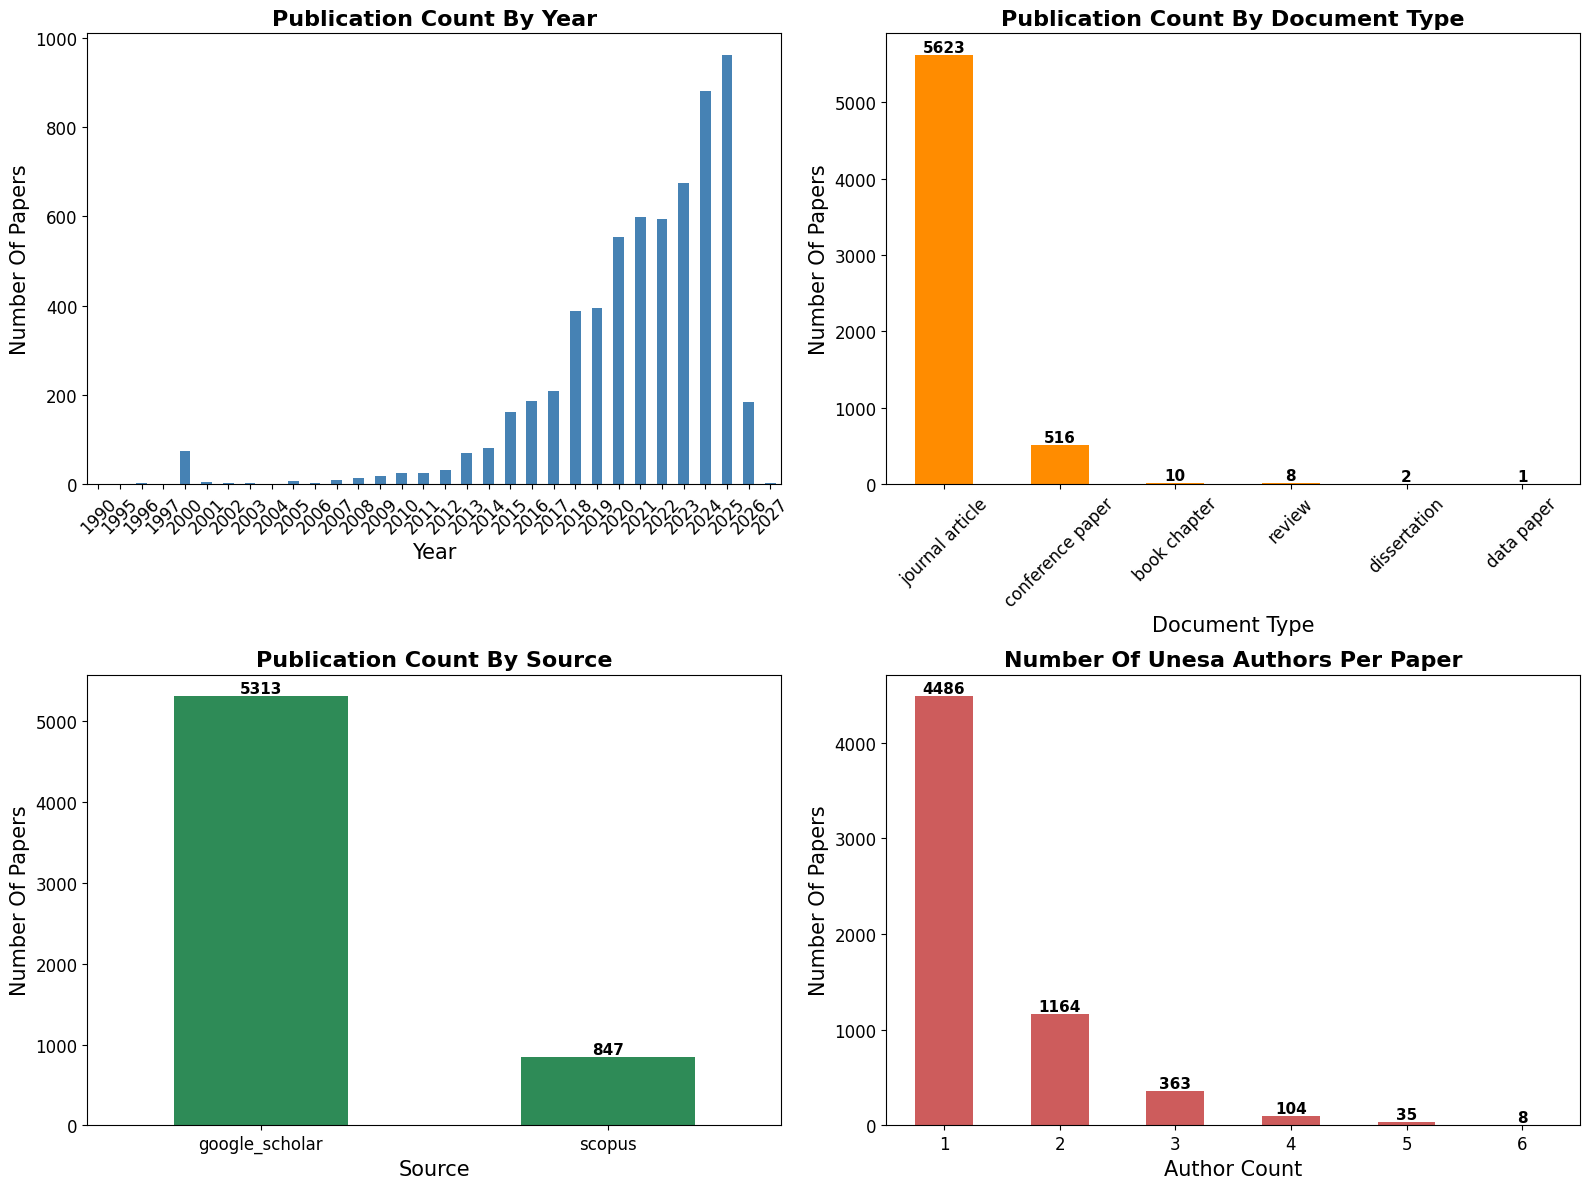

artifact registered output/viz/eda_overview_distributions.png overview of year, document type, source, and author count distributions


In [5]:
eda_df = raw_df.copy()
eda_df["author_id_list"] = eda_df["Unesa Authors"].apply(
    lambda x: [a.strip() for a in str(x).split(";") if a.strip()]
)
eda_df["n_authors"] = eda_df["author_id_list"].apply(len)

year_counts = eda_df["Year"].value_counts().sort_index()
doc_type_counts = eda_df["Document Type"].value_counts()
source_counts = eda_df["_source"].value_counts()
n_authors_counts = eda_df["n_authors"].value_counts().sort_index()

print("year range observed", eda_df["Year"].min(), "to", eda_df["Year"].max())
print(doc_type_counts)
print(source_counts)
print(n_authors_counts)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

year_counts.plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Publication Count By Year", fontsize=16, fontweight="bold")
axes[0, 0].set_xlabel("Year", fontsize=15)
axes[0, 0].set_ylabel("Number Of Papers", fontsize=15)
axes[0, 0].tick_params(axis="x", rotation=45, labelsize=12)
axes[0, 0].tick_params(axis="y", labelsize=12)

doc_type_counts.plot(kind="bar", ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Publication Count By Document Type", fontsize=16, fontweight="bold")
axes[0, 1].set_xlabel("Document Type", fontsize=15)
axes[0, 1].set_ylabel("Number Of Papers", fontsize=15)
axes[0, 1].tick_params(axis="x", rotation=45, labelsize=12)
axes[0, 1].tick_params(axis="y", labelsize=12)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

source_counts.plot(kind="bar", ax=axes[1, 0], color="seagreen")
axes[1, 0].set_title("Publication Count By Source", fontsize=16, fontweight="bold")
axes[1, 0].set_xlabel("Source", fontsize=15)
axes[1, 0].set_ylabel("Number Of Papers", fontsize=15)
axes[1, 0].tick_params(axis="x", rotation=0, labelsize=12)
axes[1, 0].tick_params(axis="y", labelsize=12)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

n_authors_counts.plot(kind="bar", ax=axes[1, 1], color="indianred")
axes[1, 1].set_title("Number Of Unesa Authors Per Paper", fontsize=16, fontweight="bold")
axes[1, 1].set_xlabel("Author Count", fontsize=15)
axes[1, 1].set_ylabel("Number Of Papers", fontsize=15)
axes[1, 1].tick_params(axis="x", rotation=0, labelsize=12)
axes[1, 1].tick_params(axis="y", labelsize=12)
for p in axes[1, 1].patches:
    axes[1, 1].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
eda_overview_path = os.path.join(OUTPUT_VIZ, "eda_overview_distributions.png")
plt.savefig(eda_overview_path, dpi=300, bbox_inches="tight")
plt.show()

register_artifact(eda_overview_path, "overview of year, document type, source, and author count distributions")

In [6]:
eda_summary_table = pd.concat(
    [
        year_counts.rename("count").rename_axis("value").reset_index().assign(dimension="year"),
        doc_type_counts.rename("count").rename_axis("value").reset_index().assign(dimension="document_type"),
        source_counts.rename("count").rename_axis("value").reset_index().assign(dimension="source"),
        n_authors_counts.rename("count").rename_axis("value").reset_index().assign(dimension="n_authors_per_paper"),
    ],
    ignore_index=True,
)
eda_summary_table = eda_summary_table[["dimension", "value", "count"]]

eda_summary_path = os.path.join(OUTPUT_ROOT, "eda_distribution_summary.csv")
eda_summary_table.to_csv(eda_summary_path, index=False)
register_artifact(eda_summary_path, "combined summary table of year, document type, source, and author count distributions")
print(eda_summary_table.head())

artifact registered output/eda_distribution_summary.csv combined summary table of year, document type, source, and author count distributions
  dimension value  count
0      year  1990      1
1      year  1995      1
2      year  1996      2
3      year  1997      1
4      year  2000     74


### Top Authors By Publication Count

total unique author ids observed 126
       author_id  publication_count                      sample_name
0   zDgqPOsAAAAJ                243                          Mustaji
1   z7RWDi0AAAAJ                242                      Tri Rijanto
2   LsydBAMAAAAJ                228          Puput Wanarti Rusimamto
3   ZhJ08JkAAAAJ                217          Bachtiar Syaiful Bachri
4   6RBIukkAAAAJ                207            Prof.Dr.Yatim Riyanto
5   p1pK7E4AAAAJ                204              Subuh Isnur Haryudo
6   MZCJPuIAAAAJ                202                    Fajar Arianto
7   6MXDzBQAAAAJ                200                     Lilik Anifah
8   yObeL8gAAAAJ                183  I Gusti Putu Asto Buditjahjanto
9   j8HRV1wAAAAJ                182                Bambang Suprianto
10  WdhKN0sAAAAJ                180                  Aditya Prapanca
11  IJIEntMAAAAJ                169                 Yeni Anistyasari
12  hjllQ9gAAAAJ                164                       Nur Khol

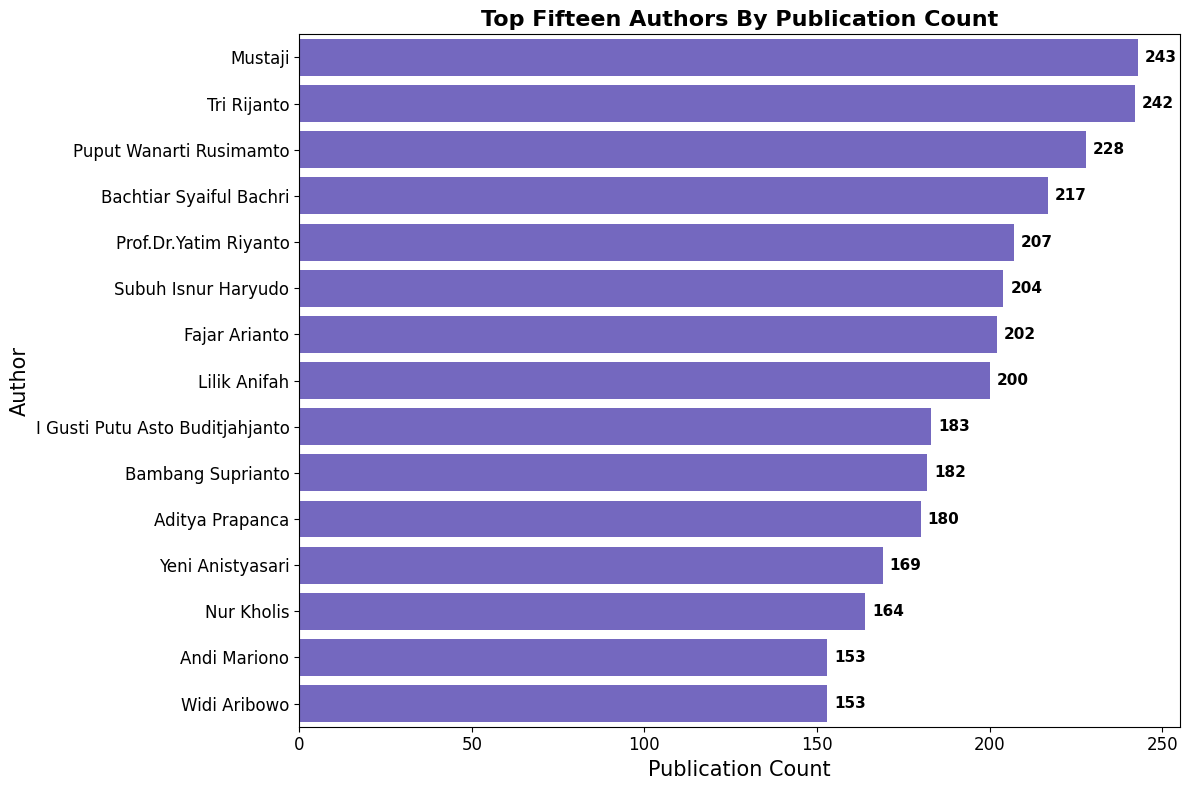

artifact registered output/viz/top_authors_by_publication_count.png bar chart of top fifteen authors by raw publication count
artifact registered output/top_authors_by_publication_count.csv full ranking of authors by raw publication count


In [7]:
author_name_pairs = []
for _, row in eda_df.iterrows():
    ids = [a.strip() for a in str(row["Unesa Authors"]).split(";") if a.strip()]
    names = [n.strip() for n in str(row["Unesa Names"]).split(";") if n.strip()]
    if len(ids) == len(names):
        for author_id, author_name in zip(ids, names):
            author_name_pairs.append((author_id, author_name))
    else:
        for author_id in ids:
            author_name_pairs.append((author_id, None))

author_pub_counts = (
    pd.DataFrame(author_name_pairs, columns=["author_id", "author_name"])
    .groupby("author_id")
    .agg(publication_count=("author_id", "count"), sample_name=("author_name", "first"))
    .sort_values("publication_count", ascending=False)
    .reset_index()
)

print("total unique author ids observed", author_pub_counts.shape[0])
top_authors = author_pub_counts.head(15)
print(top_authors)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_authors, y="sample_name", x="publication_count", ax=ax, color="slateblue")
ax.set_title("Top Fifteen Authors By Publication Count", fontsize=16, fontweight="bold")
ax.set_xlabel("Publication Count", fontsize=15)
ax.set_ylabel("Author", fontsize=15)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_width())),
        (p.get_width(), p.get_y() + p.get_height() / 2),
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
top_authors_path = os.path.join(OUTPUT_VIZ, "top_authors_by_publication_count.png")
plt.savefig(top_authors_path, dpi=300, bbox_inches="tight")
plt.show()
register_artifact(top_authors_path, "bar chart of top fifteen authors by raw publication count")

top_authors_csv_path = os.path.join(OUTPUT_ROOT, "top_authors_by_publication_count.csv")
author_pub_counts.to_csv(top_authors_csv_path, index=False)
register_artifact(top_authors_csv_path, "full ranking of authors by raw publication count")

### Missing Value Patterns And Ieee Keyword Cardinality

In [8]:
missing_pattern = pd.DataFrame(
    {
        "field": ["DOI", "Keywords"],
        "missing_count": [eda_df["DOI"].isnull().sum(), eda_df["Keywords"].isnull().sum()],
        "missing_ratio": [
            eda_df["DOI"].isnull().mean(),
            eda_df["Keywords"].isnull().mean(),
        ],
    }
)
missing_by_doc_type = (
    eda_df.assign(doi_missing=eda_df["DOI"].isnull(), keywords_missing=eda_df["Keywords"].isnull())
    .groupby("Document Type")[["doi_missing", "keywords_missing"]]
    .mean()
    .reset_index()
)
missing_by_source = (
    eda_df.assign(doi_missing=eda_df["DOI"].isnull(), keywords_missing=eda_df["Keywords"].isnull())
    .groupby("_source")[["doi_missing", "keywords_missing"]]
    .mean()
    .reset_index()
)
eda_df["n_ieee_keywords"] = eda_df["IEEE-Keywords"].apply(lambda x: len(str(x).split(";")))
ieee_keyword_count_dist = eda_df["n_ieee_keywords"].value_counts().sort_index()

n_unique_ieee_keyword_sets = eda_df["IEEE-Keywords"].nunique()
n_unique_titles = eda_df["Title"].nunique()
ieee_keyword_repetition_ratio = 1.0 - (n_unique_ieee_keyword_sets / len(eda_df))
most_common_ieee_keyword_sets = eda_df["IEEE-Keywords"].value_counts().head(5)

print(missing_pattern.to_string(index=False))
print(f"\n{missing_by_doc_type.to_string(index=False)}")
print(f"\n{missing_by_source.to_string(index=False)}")
print("\nieee keyword count distribution")
print(ieee_keyword_count_dist)
print("\nunique ieee keyword sets", n_unique_ieee_keyword_sets, "out of", len(eda_df), "rows")
print("unique titles", n_unique_titles, "out of", len(eda_df), "rows")
print("ieee keyword set repetition ratio", round(ieee_keyword_repetition_ratio, 4))
print(most_common_ieee_keyword_sets)

IEEE_KEYWORDS_TRUSTED = ieee_keyword_repetition_ratio < 0.5
print("ieee keywords field judged trustworthy for feature engineering", IEEE_KEYWORDS_TRUSTED)

missing_pattern_path = os.path.join(OUTPUT_ROOT, "missing_value_pattern.csv")
missing_by_doc_type_path = os.path.join(OUTPUT_ROOT, "missing_value_by_document_type.csv")
missing_by_source_path = os.path.join(OUTPUT_ROOT, "missing_value_by_source.csv")
ieee_keyword_dist_path = os.path.join(OUTPUT_ROOT, "ieee_keyword_count_distribution.csv")
missing_pattern.to_csv(missing_pattern_path, index=False)
missing_by_doc_type.to_csv(missing_by_doc_type_path, index=False)
missing_by_source.to_csv(missing_by_source_path, index=False)
ieee_keyword_count_dist.rename("count").rename_axis("n_ieee_keywords").reset_index().to_csv(
    ieee_keyword_dist_path, index=False
)
register_artifact(missing_pattern_path, "overall missing value ratio for doi and keywords fields")
register_artifact(missing_by_doc_type_path, "missing value ratio for doi and keywords broken down by document type")
register_artifact(missing_by_source_path, "missing value ratio for doi and keywords broken down by source")
register_artifact(ieee_keyword_dist_path, "distribution of ieee keyword count per paper and repetition diagnostic used to judge field trustworthiness")

   field  missing_count  missing_ratio
     DOI           5087       0.825812
Keywords            183       0.029708

   Document Type  doi_missing  keywords_missing
    book chapter     0.100000          0.400000
conference paper     0.027132          0.329457
      data paper     0.000000          0.000000
    dissertation     1.000000          0.000000
 journal article     0.901654          0.001601
          review     0.000000          0.000000

       _source  doi_missing  keywords_missing
google_scholar     0.946546          0.000000
        scopus     0.068477          0.216057

ieee keyword count distribution
n_ieee_keywords
5    6160
Name: count, dtype: int64

unique ieee keyword sets 5682 out of 6160 rows
unique titles 6160 out of 6160 rows
ieee keyword set repetition ratio 0.0776
IEEE-Keywords
video coding;multimedia databases;multimedia information systems;multimedia applications and multimedia signal processing;modeling structured, textual and multimedia data         15
v

### Coauthorship Edge Volume Over Time

total collaboration edge instances for eda 3347


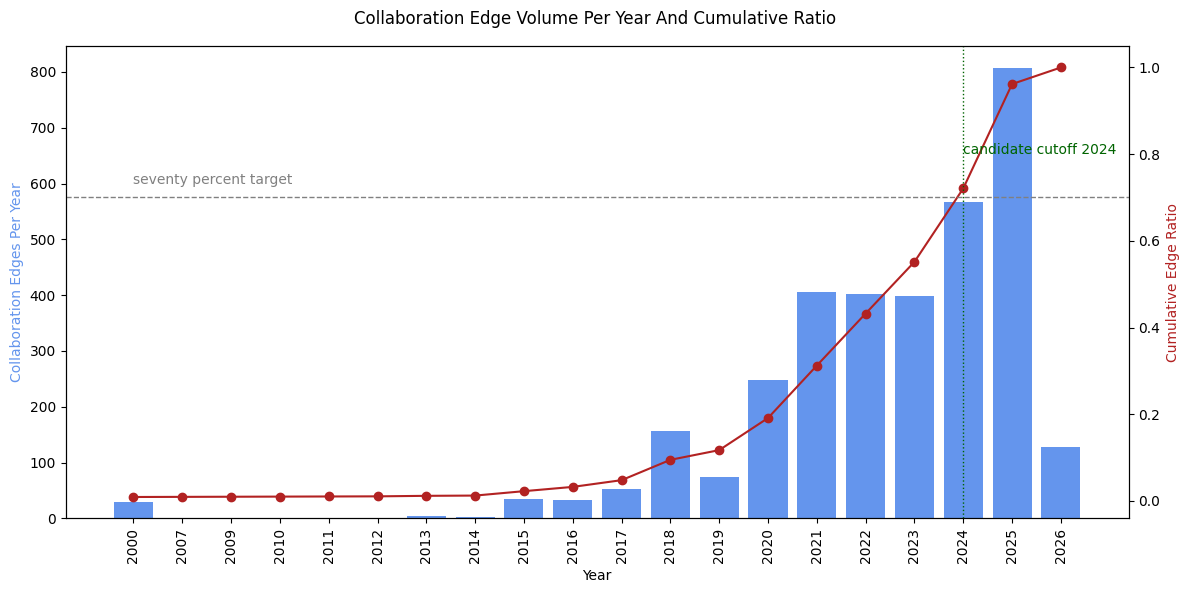

artifact registered output/viz/collaboration_edge_volume_and_cumulative_ratio.png collaboration edge volume per year with cumulative ratio used to decide temporal split cutoff
artifact registered output/collaboration_edge_volume_by_year.csv tabular edge volume and cumulative ratio per year for split cutoff decision
    year  edges_in_year  cumulative_edges  cumulative_ratio
0   2000             30                30          0.008963
1   2007              1                31          0.009262
2   2009              1                32          0.009561
3   2010              1                33          0.009860
4   2011              1                34          0.010158
5   2012              1                35          0.010457
6   2013              4                39          0.011652
7   2014              2                41          0.012250
8   2015             34                75          0.022408
9   2016             33               108          0.032268
10  2017             52

In [9]:
temporal_edge_rows = []
for _, row in eda_df.iterrows():
    ids = sorted(set(row["author_id_list"]))
    year = row["Year"]
    if len(ids) >= 2:
        for author_a, author_b in itertools.combinations(ids, 2):
            temporal_edge_rows.append((author_a, author_b, year))

temporal_edges_df = pd.DataFrame(temporal_edge_rows, columns=["author_a", "author_b", "year"])
print("total collaboration edge instances for eda", temporal_edges_df.shape[0])

edges_per_year = temporal_edges_df.groupby("year").size().sort_index()
cumulative_edges = edges_per_year.cumsum()
cumulative_ratio = cumulative_edges / cumulative_edges.iloc[-1]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(edges_per_year.index.astype(str), edges_per_year.values, color="cornflowerblue", label="Edges Per Year")
ax1.set_xlabel("Year")
ax1.set_ylabel("Collaboration Edges Per Year", color="cornflowerblue")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(edges_per_year.index.astype(str), cumulative_ratio.values, color="firebrick", marker="o", label="Cumulative Ratio")
ax2.set_ylabel("Cumulative Edge Ratio", color="firebrick")
ax2.axhline(0.7, color="gray", linestyle="dashed", linewidth=1)
ax2.annotate("seventy percent target", xy=(0, 0.7), xytext=(0, 0.73), color="gray")

for year_value, ratio_value in cumulative_ratio.items():
    if ratio_value >= 0.7:
        ax2.axvline(str(year_value), color="darkgreen", linestyle="dotted", linewidth=1)
        ax2.annotate(
            "candidate cutoff " + str(year_value),
            xy=(str(year_value), ratio_value),
            xytext=(str(year_value), min(ratio_value + 0.08, 0.98)),
            color="darkgreen",
        )
        break

fig.suptitle("Collaboration Edge Volume Per Year And Cumulative Ratio")
fig.tight_layout()
edge_volume_path = os.path.join(OUTPUT_VIZ, "collaboration_edge_volume_and_cumulative_ratio.png")
plt.savefig(edge_volume_path, dpi=150)
plt.show()
register_artifact(edge_volume_path, "collaboration edge volume per year with cumulative ratio used to decide temporal split cutoff")

edge_volume_table = pd.DataFrame(
    {
        "year": edges_per_year.index,
        "edges_in_year": edges_per_year.values,
        "cumulative_edges": cumulative_edges.values,
        "cumulative_ratio": cumulative_ratio.values,
    }
)
edge_volume_table_path = os.path.join(OUTPUT_ROOT, "collaboration_edge_volume_by_year.csv")
edge_volume_table.to_csv(edge_volume_table_path, index=False)
register_artifact(edge_volume_table_path, "tabular edge volume and cumulative ratio per year for split cutoff decision")
print(edge_volume_table)

## Data Cleaning
Menstandarkan nama penulis (menghapus gelar akademik, merapikan spasi/kapitalisasi) tetapi tetap menjadikan author id sebagai identitas kanonis, karena nama bisa berubah format tapi id tetap konsisten. Baris dengan jumlah id tidak sama dengan jumlah nama diselesaikan menggunakan lookup table id-ke-nama global, bukan dibuang, agar tidak kehilangan data.

### Author Name Normalization

In [10]:
import re

ACADEMIC_TITLE_PATTERN = re.compile(
    r"\b(Prof|Dr|Ir|Drs|Dra|M\.?Pd|M\.?T|M\.?Kom|M\.?Si|M\.?Eng|M\.?Sc|M\.?M|S\.?Pd|S\.?T|S\.?Kom|S\.?Si|S\.?E|S\.?Sos|Ph\.?D)\.?\b",
    flags=re.IGNORECASE,
)

def normalize_author_name(raw_name):
    name = str(raw_name)
    name = ACADEMIC_TITLE_PATTERN.sub(" ", name)
    name = re.sub(r"[.,]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    name = name.title()
    return name

clean_df = raw_df.copy()
clean_df["author_id_list"] = clean_df["Unesa Authors"].apply(
    lambda x: [a.strip() for a in str(x).split(";") if a.strip()]
)
clean_df["author_name_list_raw"] = clean_df["Unesa Names"].apply(
    lambda x: [a.strip() for a in str(x).split(";") if a.strip()]
)

mismatched_mask = clean_df["author_id_list"].apply(len) != clean_df["author_name_list_raw"].apply(len)
print("rows with mismatched author id and name counts", mismatched_mask.sum())
print("out of total rows", len(clean_df))

rows with mismatched author id and name counts 9
out of total rows 6160


In [11]:
consistent_rows = clean_df.loc[~mismatched_mask]
id_name_pairs_consistent = []
for ids, names in zip(consistent_rows["author_id_list"], consistent_rows["author_name_list_raw"]):
    for author_id, author_name in zip(ids, names):
        id_name_pairs_consistent.append((author_id, normalize_author_name(author_name)))

id_name_lookup_df = pd.DataFrame(id_name_pairs_consistent, columns=["author_id", "author_name"])
id_name_lookup_df = (
    id_name_lookup_df.groupby("author_id")["author_name"]
    .agg(lambda names: names.value_counts().idxmax())
    .reset_index()
)
print("canonical author id to name lookup size", id_name_lookup_df.shape[0])

canonical_name_map = dict(zip(id_name_lookup_df["author_id"], id_name_lookup_df["author_name"]))

unresolved_ids = []


def resolve_author_names(ids):
    resolved = []
    for author_id in ids:
        if author_id in canonical_name_map:
            resolved.append(canonical_name_map[author_id])
        else:
            resolved.append(None)
            unresolved_ids.append(author_id)
    return resolved


clean_df["author_name_list"] = clean_df["author_id_list"].apply(resolve_author_names)
print("author ids without any resolvable name after lookup", len(set(unresolved_ids)))
print("rows resolved using canonical id lookup instead of raw row alignment", mismatched_mask.sum())

id_name_lookup_path = os.path.join(OUTPUT_ROOT, "author_id_name_lookup.csv")
id_name_lookup_df.to_csv(id_name_lookup_path, index=False)
register_artifact(id_name_lookup_path, "deduplicated canonical author id to normalized name lookup table")

canonical author id to name lookup size 126
author ids without any resolvable name after lookup 0
rows resolved using canonical id lookup instead of raw row alignment 9
artifact registered output/author_id_name_lookup.csv deduplicated canonical author id to normalized name lookup table


In [12]:
clean_df["doi_clean"] = clean_df["DOI"].apply(lambda x: str(x).strip() if pd.notnull(x) and str(x).strip() != "" else None)
clean_df["keywords_clean"] = clean_df["Keywords"].apply(lambda x: str(x).strip() if pd.notnull(x) and str(x).strip() != "" else None)
clean_df["ieee_keyword_list"] = clean_df["IEEE-Keywords"].apply(
    lambda x: [k.strip() for k in str(x).split(";") if k.strip()]
)
clean_df["document_type_clean"] = clean_df["Document Type"].apply(
    lambda x: str(x).strip().lower() if pd.notnull(x) and str(x).strip() != "" else None
)
clean_df["paper_id"] = clean_df.index.astype(str)

SENTINEL_YEAR_VALUES = [2000]
clean_df["year_is_reliable"] = ~clean_df["Year"].isin(SENTINEL_YEAR_VALUES)
n_sentinel_year_rows = (~clean_df["year_is_reliable"]).sum()
print("rows flagged with sentinel or default year value", n_sentinel_year_rows)
print("sentinel year values treated as unreliable", SENTINEL_YEAR_VALUES)

clean_papers_df = clean_df[
    [
        "paper_id",
        "Title",
        "Year",
        "Journal",
        "keywords_clean",
        "document_type_clean",
        "doi_clean",
        "author_id_list",
        "author_name_list",
        "ieee_keyword_list",
        "_source",
        "year_is_reliable",
    ]
].rename(columns={"Title": "title", "Year": "year", "Journal": "journal", "_source": "source"})

print("cleaned paper table shape", clean_papers_df.shape)

clean_papers_path = os.path.join(OUTPUT_ROOT, "clean_papers.csv")
clean_papers_df.to_csv(clean_papers_path, index=False)
register_artifact(clean_papers_path, "cleaned paper level table with normalized authors, standardized document type, and year reliability flag")

rows flagged with sentinel or default year value 74
sentinel year values treated as unreliable [2000]
cleaned paper table shape (6160, 12)
artifact registered output/clean_papers.csv cleaned paper level table with normalized authors, standardized document type, and year reliability flag


## Feature Engineering

### Paper Level Sentence Embeddings
Judul dan keyword digabung lalu diencode dengan model sentence embedding agar makna semantik paper (bukan hanya keyword) dapat ditangkap.

In [13]:
sentence_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
sentence_model.to(DEVICE)
print("sentence embedding model loaded", sentence_model.get_sentence_embedding_dimension())

def build_paper_text(title, keywords):
    keyword_part = keywords if isinstance(keywords, str) and keywords.strip() != "" else ""
    combined = str(title)
    if keyword_part:
        combined = combined + " . " + keyword_part
    return combined


clean_papers_df["embedding_text"] = clean_papers_df.apply(
    lambda row: build_paper_text(row["title"], row["keywords_clean"]), axis=1
)

paper_embeddings = sentence_model.encode(
    clean_papers_df["embedding_text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print("paper embedding matrix shape", paper_embeddings.shape)

paper_embedding_columns = [f"embed_{i}" for i in range(paper_embeddings.shape[1])]
paper_embedding_df = pd.DataFrame(paper_embeddings, columns=paper_embedding_columns)
paper_embedding_df.insert(0, "paper_id", clean_papers_df["paper_id"].values)

paper_embedding_path = os.path.join(OUTPUT_ROOT, "paper_embeddings.csv")
paper_embedding_df.to_csv(paper_embedding_path, index=False)
register_artifact(paper_embedding_path, "sentence embedding vector per paper built from title and keywords")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

sentence embedding model loaded 384


Batches:   0%|          | 0/97 [00:00<?, ?it/s]

paper embedding matrix shape (6160, 384)
artifact registered output/paper_embeddings.csv sentence embedding vector per paper built from title and keywords


### Author Content Embeddings Full And Historical
Dibuat dua versi terpisah, versi penuh (seluruh riwayat publikasi) untuk expert retrieval yang tidak dibatasi waktu, dan versi historis (hanya sampai tahun cutoff) khusus untuk link prediction agar tidak terjadi kebocoran informasi masa depan ke fitur yang memprediksi struktur masa lalu.

In [14]:
def compute_author_content_embeddings(papers_df, embedding_matrix, year_cutoff=None):
    if year_cutoff is not None:
        eligible_mask = papers_df["year"] <= year_cutoff
    else:
        eligible_mask = pd.Series(True, index=papers_df.index)

    eligible_papers = papers_df.loc[eligible_mask]
    eligible_embeddings = embedding_matrix[eligible_mask.values]

    author_vectors = {}
    author_paper_counts = {}
    for row_position, (_, paper_row) in enumerate(eligible_papers.iterrows()):
        embedding_vector = eligible_embeddings[row_position]
        for author_id in paper_row["author_id_list"]:
            if author_id not in author_vectors:
                author_vectors[author_id] = []
                author_paper_counts[author_id] = 0
            author_vectors[author_id].append(embedding_vector)
            author_paper_counts[author_id] += 1

    author_ids_sorted = sorted(author_vectors.keys())
    stacked_matrix = np.stack([np.mean(author_vectors[author_id], axis=0) for author_id in author_ids_sorted])

    result_df = pd.DataFrame(stacked_matrix, columns=paper_embedding_columns)
    result_df.insert(0, "author_id", author_ids_sorted)
    result_df.insert(1, "n_papers_used", [author_paper_counts[author_id] for author_id in author_ids_sorted])

    return result_df, eligible_papers.shape[0]


author_content_embedding_full, n_papers_full = compute_author_content_embeddings(
    clean_papers_df, paper_embeddings, year_cutoff=None
)
print("full author content embedding covers authors", author_content_embedding_full.shape[0])
print("full version built from paper count", n_papers_full)

author_content_embedding_full_path = os.path.join(OUTPUT_ROOT, "author_content_embedding_full.csv")
author_content_embedding_full.to_csv(author_content_embedding_full_path, index=False)
register_artifact(author_content_embedding_full_path, "author content embedding using entire publication history, used for expert retrieval")

full author content embedding covers authors 126
full version built from paper count 6160
artifact registered output/author_content_embedding_full.csv author content embedding using entire publication history, used for expert retrieval


In [15]:
def build_author_content_embedding_historical(year_cutoff):
    historical_df, n_papers_historical = compute_author_content_embeddings(
        clean_papers_df, paper_embeddings, year_cutoff=year_cutoff
    )
    max_year_used = clean_papers_df.loc[clean_papers_df["year"] <= year_cutoff, "year"].max()
    print("historical author content embedding cutoff year", year_cutoff)
    print("historical version built from paper count", n_papers_historical)
    print("max publication year actually included", max_year_used)
    print(
        "validation no future paper leaked",
        bool(max_year_used <= year_cutoff),
    )
    return historical_df

print("historical author content embedding builder function ready, to be called after split cutoff year is determined")
print("comparison of paper counts, full version uses", n_papers_full, "papers out of", clean_papers_df.shape[0], "total papers")

historical author content embedding builder function ready, to be called after split cutoff year is determined
comparison of paper counts, full version uses 6160 papers out of 6160 total papers


### Author Temporal Activity Features
Menghitung total publikasi, publikasi per tipe dokumen, serta tahun aktif pertama dan terakhir, sebagai fitur aktivitas non-tekstual.

In [16]:
author_activity_rows = []
paper_author_long = clean_papers_df.explode("author_id_list").rename(columns={"author_id_list": "author_id"})
paper_author_long = paper_author_long.dropna(subset=["author_id"])

for author_id, group in paper_author_long.groupby("author_id"):
    doc_type_counts = group["document_type_clean"].value_counts().to_dict()
    author_activity_rows.append(
        {
            "author_id": author_id,
            "total_publications": group.shape[0],
            "n_journal_article": doc_type_counts.get("journal article", 0),
            "n_conference_paper": doc_type_counts.get("conference paper", 0),
            "n_book_chapter": doc_type_counts.get("book chapter", 0),
            "n_review": doc_type_counts.get("review", 0),
            "n_other_document_type": group.shape[0]
            - doc_type_counts.get("journal article", 0)
            - doc_type_counts.get("conference paper", 0)
            - doc_type_counts.get("book chapter", 0)
            - doc_type_counts.get("review", 0),
            "first_active_year": int(group["year"].min()),
            "last_active_year": int(group["year"].max()),
        }
    )

author_activity_df = pd.DataFrame(author_activity_rows)
print("author activity feature table shape", author_activity_df.shape)
print(author_activity_df.describe())

author activity feature table shape (126, 9)
       total_publications  n_journal_article  n_conference_paper  \
count          126.000000         126.000000          126.000000   
mean            67.793651          60.904762            6.650794   
std             59.765183          57.216561            7.135620   
min              1.000000           0.000000            0.000000   
25%             21.250000          17.500000            2.000000   
50%             50.500000          44.000000            4.000000   
75%             92.250000          83.750000           10.000000   
max            243.000000         237.000000           35.000000   

       n_book_chapter    n_review  n_other_document_type  first_active_year  \
count      126.000000  126.000000             126.000000         126.000000   
mean         0.150794    0.063492               0.023810        2009.190476   
std          0.507030    0.244819               0.153064           8.421605   
min          0.000000    0

### Coauthorship Graph Structural Features
Menghitung degree, clustering coefficient, dan core number dari graph proyeksi coauthorship untuk menangkap posisi struktural penulis dalam jaringan kolaborasi.

In [17]:
coauthor_projection_graph = nx.Graph()
coauthor_projection_graph.add_nodes_from(author_activity_df["author_id"].tolist())

for _, paper_row in clean_papers_df.iterrows():
    unique_authors = sorted(set(paper_row["author_id_list"]))
    if len(unique_authors) >= 2:
        for author_a, author_b in itertools.combinations(unique_authors, 2):
            if coauthor_projection_graph.has_edge(author_a, author_b):
                coauthor_projection_graph[author_a][author_b]["weight"] += 1
            else:
                coauthor_projection_graph.add_edge(author_a, author_b, weight=1)

print("coauthor projection graph nodes", coauthor_projection_graph.number_of_nodes())
print("coauthor projection graph edges", coauthor_projection_graph.number_of_edges())

degree_dict = dict(coauthor_projection_graph.degree())
clustering_dict = nx.clustering(coauthor_projection_graph)
core_number_dict = nx.core_number(coauthor_projection_graph)

structural_feature_df = pd.DataFrame(
    {
        "author_id": list(degree_dict.keys()),
        "degree": list(degree_dict.values()),
        "clustering_coefficient": [clustering_dict[a] for a in degree_dict.keys()],
        "core_number": [core_number_dict[a] for a in degree_dict.keys()],
    }
)
print(structural_feature_df.describe())

coauthor projection graph nodes 126
coauthor projection graph edges 1154
           degree  clustering_coefficient  core_number
count  126.000000              126.000000   126.000000
mean    18.317460                0.405767    10.611111
std     10.096059                0.182530     3.568691
min      0.000000                0.000000     0.000000
25%     11.250000                0.303427     9.000000
50%     17.000000                0.363333    13.000000
75%     26.000000                0.483578    13.000000
max     41.000000                1.000000    13.000000


In [18]:
author_feature_table = (
    author_activity_df.merge(structural_feature_df, on="author_id", how="left")
    .merge(id_name_lookup_df, on="author_id", how="left")
)
print("final author feature table shape", author_feature_table.shape)
print(author_feature_table.head())

author_feature_table_path = os.path.join(OUTPUT_ROOT, "author_feature_table.csv")
author_feature_table.to_csv(author_feature_table_path, index=False)
register_artifact(author_feature_table_path, "author level activity and structural feature table")

final author feature table shape (126, 13)
      author_id  total_publications  n_journal_article  n_conference_paper  \
0  -BuJoD0AAAAJ                  28                 21                   7   
1  -_VNTSIAAAAJ                  10                  5                   4   
2  -gGGkMcAAAAJ                  16                 16                   0   
3  -tpBKawAAAAJ                  10                  8                   2   
4  1hm7MM8AAAAJ                  81                 69                  12   

   n_book_chapter  n_review  n_other_document_type  first_active_year  \
0               0         0                      0               2015   
1               0         0                      1               2012   
2               0         0                      0               2000   
3               0         0                      0               2017   
4               0         0                      0               2000   

   last_active_year  degree  clustering_coefficie

## Topic Extraction
Topik ditemukan menggunakan embedding based clustering (UMAP + HDBSCAN)

Note:
Sebelumnya sempat mencoba GliNER dan keyword co-occurrence graph dengan modularity maximization tapi terkendala resolution limit sehingga topik yang dihasilkan terlalu sedikit dan didominasi keyword generik, yang juga menyebabkan hasil Expert Retrieval menjadi bias/tidak akurat.

### Dimensionality Reduction With Umap
Mereduksi dimensi embedding paper agar struktur cluster lebih mudah ditemukan oleh HDBSCAN.

In [19]:
umap_reducer = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_SEED,
)
paper_embedding_reduced = umap_reducer.fit_transform(paper_embeddings)
print("umap reduced embedding shape", paper_embedding_reduced.shape)

umap_2d_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=RANDOM_SEED,
)
paper_embedding_2d = umap_2d_reducer.fit_transform(paper_embeddings)
print("umap two dimensional embedding shape for visualization", paper_embedding_2d.shape)

umap reduced embedding shape (6160, 5)
umap two dimensional embedding shape for visualization (6160, 2)


### Hdbscan Parameter Grid Search
Mencoba berbagai kombinasi min_cluster_size dan min_samples, lalu memilih kombinasi terbaik berdasarkan DBCV (Density Based Clustering Validation) index tertinggi, bukan berdasarkan ambang batas yang ditentukan secara manual.

In [20]:
min_cluster_size_candidates = [15, 25, 40, 60, 90]
min_samples_candidates = [5, 10, 15]

grid_search_rows = []
for min_cluster_size in min_cluster_size_candidates:
    for min_samples in min_samples_candidates:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size, min_samples=min_samples, gen_min_span_tree=True
        )
        candidate_labels = clusterer.fit_predict(paper_embedding_reduced)
        n_clusters = len(set(candidate_labels)) - (1 if -1 in candidate_labels else 0)
        noise_ratio = float(np.mean(candidate_labels == -1))
        validity_index = float(clusterer.relative_validity_) if n_clusters >= 2 else float("-inf")
        grid_search_rows.append(
            {
                "min_cluster_size": min_cluster_size,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "dbcv_validity_index": validity_index,
            }
        )
        print(
            "min cluster size", min_cluster_size,
            "min samples", min_samples,
            "n clusters", n_clusters,
            "noise ratio", round(noise_ratio, 4),
            "dbcv validity index", round(validity_index, 4),
        )

hdbscan_grid_df = pd.DataFrame(grid_search_rows)
hdbscan_grid_path = os.path.join(OUTPUT_ROOT, "hdbscan_grid_search.csv")
hdbscan_grid_df.to_csv(hdbscan_grid_path, index=False)
register_artifact(hdbscan_grid_path, "hdbscan parameter grid search results with cluster count, noise ratio, and dbcv validity index per combination")

min cluster size 15 min samples 5 n clusters 105 noise ratio 0.2911 dbcv validity index 0.2286
min cluster size 15 min samples 10 n clusters 94 noise ratio 0.3521 dbcv validity index 0.2029
min cluster size 15 min samples 15 n clusters 77 noise ratio 0.3718 dbcv validity index 0.1944
min cluster size 25 min samples 5 n clusters 70 noise ratio 0.3222 dbcv validity index 0.2256
min cluster size 25 min samples 10 n clusters 59 noise ratio 0.3167 dbcv validity index 0.2852
min cluster size 25 min samples 15 n clusters 57 noise ratio 0.3532 dbcv validity index 0.1785
min cluster size 40 min samples 5 n clusters 2 noise ratio 0.0 dbcv validity index 0.1205
min cluster size 40 min samples 10 n clusters 2 noise ratio 0.0 dbcv validity index 0.1183
min cluster size 40 min samples 15 n clusters 2 noise ratio 0.0021 dbcv validity index 0.0586
min cluster size 60 min samples 5 n clusters 2 noise ratio 0.0 dbcv validity index 0.1205
min cluster size 60 min samples 10 n clusters 2 noise ratio 0.0 db

selected hdbscan min cluster size 25
selected hdbscan min samples 10
selection criterion is the highest dbcv relative validity index across the grid, an objective internal cluster validity measure
selected combination yields n clusters 59 noise ratio 0.3167 dbcv validity index 0.2852


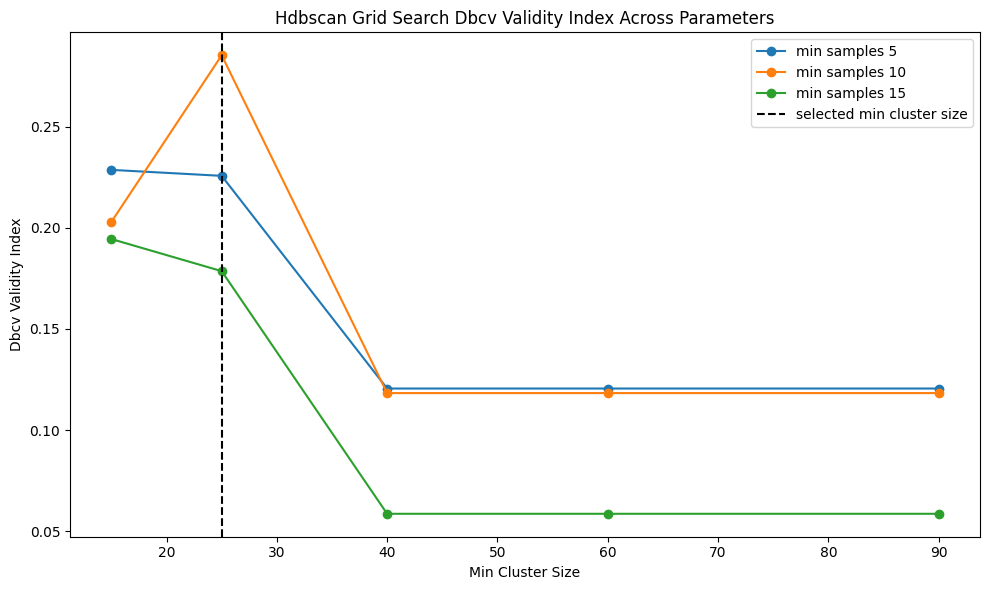

artifact registered output/viz/hdbscan_grid_search_noise_ratio.png dbcv validity index across hdbscan parameter grid search used to objectively justify parameter selection


In [21]:
candidate_pool = hdbscan_grid_df[hdbscan_grid_df["n_clusters"] >= 2]
selected_params = candidate_pool.sort_values("dbcv_validity_index", ascending=False).iloc[0]
selected_min_cluster_size = int(selected_params["min_cluster_size"])
selected_min_samples = int(selected_params["min_samples"])
print("selected hdbscan min cluster size", selected_min_cluster_size)
print("selected hdbscan min samples", selected_min_samples)
print(
    "selection criterion is the highest dbcv relative validity index across the grid, an objective internal cluster validity measure"
)
print(
    "selected combination yields n clusters", int(selected_params["n_clusters"]),
    "noise ratio", round(selected_params["noise_ratio"], 4),
    "dbcv validity index", round(selected_params["dbcv_validity_index"], 4),
)

fig, ax = plt.subplots(figsize=(10, 6))
for min_samples in min_samples_candidates:
    subset = hdbscan_grid_df[hdbscan_grid_df["min_samples"] == min_samples]
    ax.plot(subset["min_cluster_size"], subset["dbcv_validity_index"], marker="o", label=f"min samples {min_samples}")
ax.axvline(selected_min_cluster_size, color="black", linestyle="dashed", label="selected min cluster size")
ax.set_xlabel("Min Cluster Size")
ax.set_ylabel("Dbcv Validity Index")
ax.set_title("Hdbscan Grid Search Dbcv Validity Index Across Parameters")
ax.legend()
plt.tight_layout()
hdbscan_grid_viz_path = os.path.join(OUTPUT_VIZ, "hdbscan_grid_search_noise_ratio.png")
plt.savefig(hdbscan_grid_viz_path, dpi=150)
plt.show()
register_artifact(hdbscan_grid_viz_path, "dbcv validity index across hdbscan parameter grid search used to objectively justify parameter selection")

In [22]:
final_clusterer = hdbscan.HDBSCAN(min_cluster_size=selected_min_cluster_size, min_samples=selected_min_samples)
topic_labels = final_clusterer.fit_predict(paper_embedding_reduced)

clean_papers_df["topic_id"] = topic_labels
n_topics_found = len(set(topic_labels)) - (1 if -1 in topic_labels else 0)
print("final number of topics discovered", n_topics_found)
print("final noise ratio", float(np.mean(topic_labels == -1)))
print(clean_papers_df["topic_id"].value_counts().sort_index())

final number of topics discovered 59
final noise ratio 0.31672077922077924
topic_id
-1     1951
 0      137
 1       26
 2       31
 3       53
 4       77
 5       49
 6       28
 7       35
 8       48
 9       83
 10      32
 11      47
 12      36
 13      56
 14      58
 15      48
 16      58
 17      63
 18      48
 19      29
 20     134
 21      85
 22      34
 23     131
 24     378
 25      50
 26      61
 27      80
 28     178
 29      53
 30      26
 31      63
 32      35
 33      38
 34      58
 35      41
 36      28
 37      29
 38      41
 39     169
 40      34
 41     144
 42      45
 43      26
 44      53
 45     368
 46      25
 47      60
 48      34
 49      32
 50      52
 51      60
 52      34
 53     146
 54      25
 55     106
 56      64
 57     105
 58      42
Name: count, dtype: int64


Paper yang oleh HDBSCAN diberi label noise (-1) tidak dibuang dari analisis topik, melainkan di-assign ke centroid cluster terdekat berdasarkan metrik euclidian (default HDBSCAN).

In [23]:
noise_mask = topic_labels == -1
non_noise_topic_ids = sorted(set(topic_labels) - {-1})
cluster_centroids = np.stack([
    paper_embedding_reduced[topic_labels == topic_id].mean(axis=0) for topic_id in non_noise_topic_ids
])
noise_indices = np.where(noise_mask)[0]
distances_to_centroids = np.linalg.norm(
    paper_embedding_reduced[noise_indices][:, None, :] - cluster_centroids[None, :, :], axis=2
)
nearest_centroid_positions = distances_to_centroids.argmin(axis=1)
reassigned_labels = topic_labels.copy()
for position, noise_index in enumerate(noise_indices):
    reassigned_labels[noise_index] = non_noise_topic_ids[nearest_centroid_positions[position]]

clean_papers_df["topic_id"] = reassigned_labels
clean_papers_df["topic_assignment_method"] = np.where(noise_mask, "centroid_reassigned", "density_native")

print("papers originally flagged as noise by hdbscan", int(noise_mask.sum()))
print("papers remaining as noise after centroid reassignment", int((clean_papers_df["topic_id"] == -1).sum()))
print(clean_papers_df["topic_assignment_method"].value_counts())
print(clean_papers_df["topic_id"].value_counts().sort_index())

topic_assignment_summary_path = os.path.join(OUTPUT_ROOT, "topic_assignment_method_summary.csv")
clean_papers_df["topic_assignment_method"].value_counts().rename("count").rename_axis("assignment_method").reset_index().to_csv(
    topic_assignment_summary_path, index=False
)
register_artifact(topic_assignment_summary_path, "count of papers assigned by native hdbscan density clustering versus centroid reassignment for former noise papers")

papers originally flagged as noise by hdbscan 1951
papers remaining as noise after centroid reassignment 0
topic_assignment_method
density_native         4209
centroid_reassigned    1951
Name: count, dtype: int64
topic_id
0     137
1      40
2      34
3     103
4     102
5      53
6      30
7      35
8      84
9      97
10     35
11     60
12    103
13     73
14     61
15     60
16     70
17     90
18     57
19     51
20    141
21     87
22     54
23    213
24    442
25     98
26     99
27    125
28    289
29    144
30     58
31    111
32     58
33     42
34     95
35     59
36     39
37     31
38     69
39    186
40     40
41    191
42     74
43     45
44    138
45    477
46     35
47    119
48     41
49     67
50     67
51     83
52    128
53    200
54     78
55    134
56    131
57    155
58    142
Name: count, dtype: int64
artifact registered output/topic_assignment_method_summary.csv count of papers assigned by native hdbscan density clustering versus centroid reassignment for form

### Automatic Topic Labeling With Class Based Tfidf
Label topik dihasilkan otomatis dari kata dengan skor c-TF-IDF tertinggi pada tiap cluster, tanpa penamaan manual, agar prosesnya tetap reproducible dan objektif.

In [24]:
def build_topic_document(rows):
    combined_terms = []
    for _, row in rows.iterrows():
        combined_terms.append(str(row["title"]))
        if isinstance(row["keywords_clean"], str) and row["keywords_clean"].strip() != "":
            combined_terms.append(row["keywords_clean"])
    return " . ".join(combined_terms)


topic_documents = {}
for topic_id, group in clean_papers_df[clean_papers_df["topic_id"] != -1].groupby("topic_id"):
    topic_documents[topic_id] = build_topic_document(group)

topic_ids_ordered = sorted(topic_documents.keys())
class_tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2))
class_tfidf_matrix = class_tfidf_vectorizer.fit_transform([topic_documents[t] for t in topic_ids_ordered])
vocabulary = np.array(class_tfidf_vectorizer.get_feature_names_out())

topic_label_rows = []
for row_index, topic_id in enumerate(topic_ids_ordered):
    row_scores = class_tfidf_matrix[row_index].toarray().flatten()
    top_term_indices = row_scores.argsort()[::-1][:6]
    top_terms = vocabulary[top_term_indices].tolist()
    topic_label_rows.append({"topic_id": topic_id, "topic_label": ", ".join(top_terms), "n_papers": int((clean_papers_df["topic_id"] == topic_id).sum())})

topic_label_df = pd.DataFrame(topic_label_rows).sort_values("n_papers", ascending=False)
print(topic_label_df)

topic_label_path = os.path.join(OUTPUT_ROOT, "topic_labels.csv")
topic_label_df.to_csv(topic_label_path, index=False)
register_artifact(topic_label_path, "automatic topic labels derived from class based tfidf top terms per cluster")

    topic_id                                        topic_label  n_papers
45        45  learning, strategies, teaching, student, colla...       477
24        24  iot, monitoring, iot iot, things, internet thi...       442
28        28  classification, data, mining, vector, support ...       289
23        23  energy, renewable energy, renewable, energy re...       213
53        53  qualitative, qualitative research, research, r...       200
41        41  video, video understanding, video analysis, un...       191
39        39  learning, online learning, online, learning on...       186
57        57  web, educational, qualitative, information, in...       155
29        29  blockchain, twitter, text, sentiment, sentimen...       144
58        58  qualitative, qualitative research, research, r...       142
20        20  optimization, algorithm, neural, metaheuristic...       141
44        44  learning, media, technology, educational, educ...       138
0          0  game, game theory, gamif

In [25]:
paper_topic_assignment_df = clean_papers_df[["paper_id", "topic_id"]].merge(
    topic_label_df[["topic_id", "topic_label"]], on="topic_id", how="left"
)
paper_topic_assignment_df["topic_label"] = paper_topic_assignment_df["topic_label"].fillna("noise unassigned")
print("paper topic assignment shape", paper_topic_assignment_df.shape)

paper_topic_assignment_path = os.path.join(OUTPUT_ROOT, "paper_topic_assignment.csv")
paper_topic_assignment_df.to_csv(paper_topic_assignment_path, index=False)
register_artifact(paper_topic_assignment_path, "topic id and automatic label assigned to every paper")

paper topic assignment shape (6160, 3)
artifact registered output/paper_topic_assignment.csv topic id and automatic label assigned to every paper


### Author Topic Profile And Topical Sub Embeddings
Selain hitungan publikasi per topik, dihitung juga sub-embedding topikal (rata-rata embedding hanya dari paper penulis pada topik tertentu), terpisah dari embedding global penulis, agar spesialis dengan jumlah paper sedikit di suatu topik tidak "tenggelam" oleh rata-rata seluruh riwayat publikasinya.

In [26]:
paper_topic_long = clean_papers_df[["paper_id", "author_id_list", "topic_id"]].explode("author_id_list")
paper_topic_long = paper_topic_long.rename(columns={"author_id_list": "author_id"}).dropna(subset=["author_id"])
paper_topic_long_valid = paper_topic_long[paper_topic_long["topic_id"] != -1]

topic_profile_matrix = (
    paper_topic_long_valid.groupby(["author_id", "topic_id"])
    .size()
    .unstack(fill_value=0)
)
topic_profile_matrix.columns = [f"topic_{c}_count" for c in topic_profile_matrix.columns]
topic_profile_matrix = topic_profile_matrix.reset_index()
print("topic profile matrix shape", topic_profile_matrix.shape)

topic_profile_path = os.path.join(OUTPUT_ROOT, "author_topic_profile_matrix.csv")
topic_profile_matrix.to_csv(topic_profile_path, index=False)
register_artifact(topic_profile_path, "author by topic publication count matrix")

topic profile matrix shape (126, 60)
artifact registered output/author_topic_profile_matrix.csv author by topic publication count matrix


In [27]:
paper_id_to_embedding = dict(zip(clean_papers_df["paper_id"], paper_embeddings))

author_topic_sub_embedding_rows = []
for (author_id, topic_id), group in paper_topic_long_valid.groupby(["author_id", "topic_id"]):
    paper_ids_in_group = group["paper_id"].tolist()
    vectors = np.stack([paper_id_to_embedding[pid] for pid in paper_ids_in_group])
    mean_vector = vectors.mean(axis=0)
    row = {"author_id": author_id, "topic_id": topic_id, "n_papers_in_topic": len(paper_ids_in_group)}
    for i, value in enumerate(mean_vector):
        row[f"topic_embed_{i}"] = value
    author_topic_sub_embedding_rows.append(row)

author_topic_sub_embedding_df = pd.DataFrame(author_topic_sub_embedding_rows)
print("author topical sub embedding table shape", author_topic_sub_embedding_df.shape)

author_topic_sub_embedding_path = os.path.join(OUTPUT_ROOT, "author_topic_sub_embeddings.csv")
author_topic_sub_embedding_df.to_csv(author_topic_sub_embedding_path, index=False)
register_artifact(author_topic_sub_embedding_path, "per author per topic mean embedding computed only from that authors papers in the topic")

author topical sub embedding table shape (2555, 387)
artifact registered output/author_topic_sub_embeddings.csv per author per topic mean embedding computed only from that authors papers in the topic


### Topic Space And Topic Size Visualizations

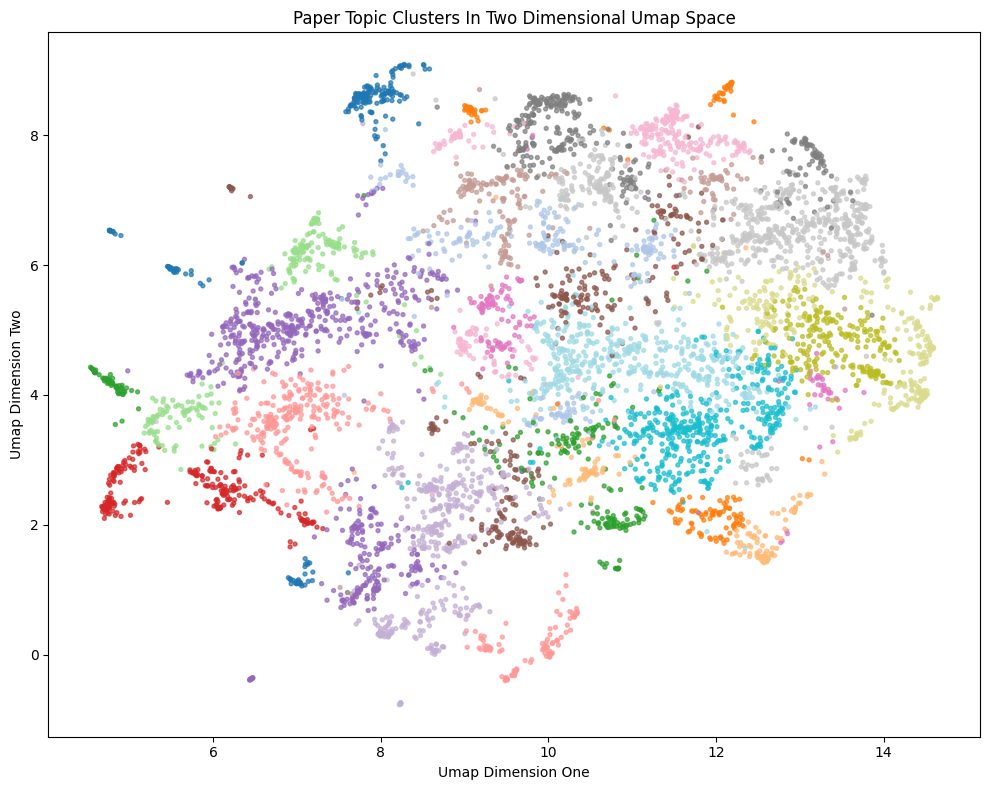

artifact registered output/viz/topic_clusters_umap_scatter.png two dimensional umap scatter of papers colored by discovered topic cluster


In [28]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter_colors = clean_papers_df["topic_id"].values
scatter_plot = ax.scatter(
    paper_embedding_2d[:, 0],
    paper_embedding_2d[:, 1],
    c=scatter_colors,
    cmap="tab20",
    s=8,
    alpha=0.7,
)
ax.set_title("Paper Topic Clusters In Two Dimensional Umap Space")
ax.set_xlabel("Umap Dimension One")
ax.set_ylabel("Umap Dimension Two")
plt.tight_layout()
topic_scatter_path = os.path.join(OUTPUT_VIZ, "topic_clusters_umap_scatter.png")
plt.savefig(topic_scatter_path, dpi=150)
plt.show()
register_artifact(topic_scatter_path, "two dimensional umap scatter of papers colored by discovered topic cluster")

In [29]:
import plotly.express as px

plot_df = clean_papers_df.copy()
plot_df["umap_x"] = paper_embedding_2d[:, 0]
plot_df["umap_y"] = paper_embedding_2d[:, 1]
plot_df = plot_df.merge(
    topic_label_df[["topic_id", "topic_label"]],
    on="topic_id",
    how="left"
)
plot_df["topic_label"] = plot_df["topic_label"].fillna("Noise")

fig = px.scatter(
    plot_df,
    x="umap_x",
    y="umap_y",
    color=plot_df["topic_id"].astype(str),
    hover_data={
        "topic_id": True,
        "topic_label": True,
        "title": True,
        "umap_x": False,
        "umap_y": False,
    },
    labels={
        "umap_x": "Umap Dimension One",
        "umap_y": "Umap Dimension Two",
        "color": "Topic ID"
    },
    title="Paper Topic Clusters In Two Dimensional Umap Space",
    opacity=0.7
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(title_font_size=16, font_size=12, showlegend=False)

topic_scatter_path = os.path.join(OUTPUT_VIZ, "topic_clusters_umap_scatter.html")
fig.write_html(topic_scatter_path)
fig.show()
register_artifact(topic_scatter_path, "interactive two dimensional umap scatter of papers colored by discovered topic cluster")

artifact registered output/viz/topic_clusters_umap_scatter.html interactive two dimensional umap scatter of papers colored by discovered topic cluster


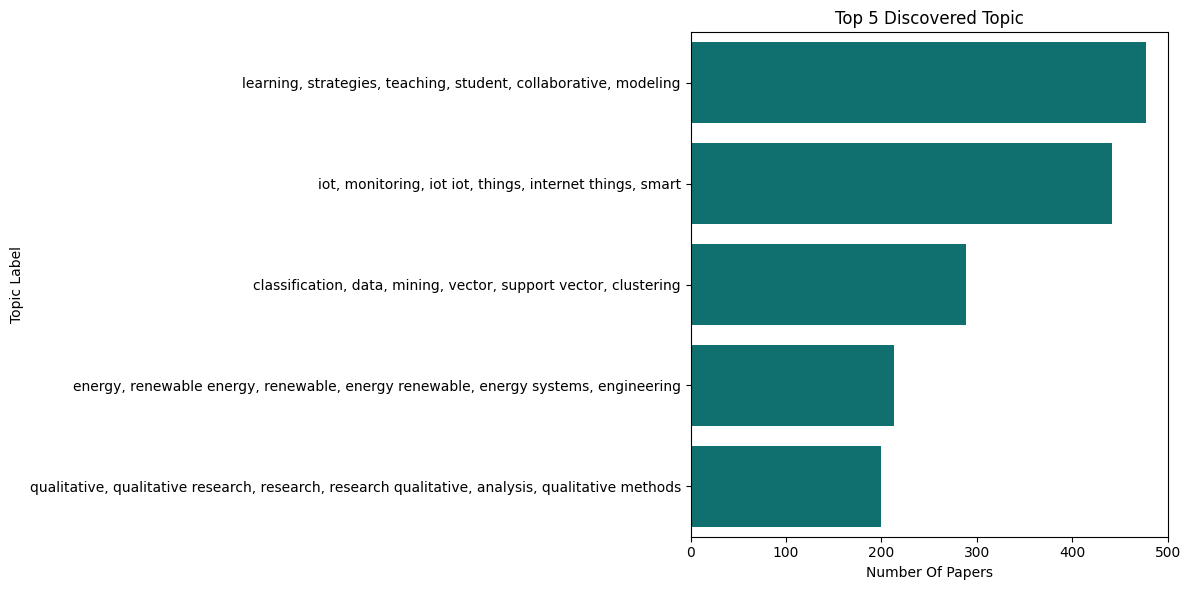

artifact registered output/viz/top5_topic_distribution.png bar chart of paper count per discovered topic with automatic labels


In [62]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_order = topic_label_df.head(5).sort_values("n_papers", ascending=False)
sns.barplot(data=plot_order, x="n_papers", y="topic_label", ax=ax, color="teal")
ax.set_title("Top 5 Discovered Topic")
ax.set_xlabel("Number Of Papers")
ax.set_ylabel("Topic Label")
plt.tight_layout()
topic_size_path = os.path.join(OUTPUT_VIZ, "top5_topic_distribution.png")
plt.savefig(topic_size_path, dpi=150)
plt.show()
register_artifact(topic_size_path, "bar chart of paper count per discovered topic with automatic labels")

## Knowledge Graph Construction
Membangun knowledge graph multi-relasi dengan empat tipe entitas (author, paper, topic, journal) dan lima tipe relasi (writes, has topic, published in, coauthored journal, coauthored conference). Relasi coauthorship sengaja dipisah menjadi jurnal dan konferensi karena kedua jenis kolaborasi ini punya bobot kepentingan berbeda di tahap pemodelan berikutnya.

### Entity And Relation Assembly

In [31]:
triple_rows = []

for _, paper_row in clean_papers_df.iterrows():
    paper_entity = f"paper::{paper_row['paper_id']}"
    for author_id in paper_row["author_id_list"]:
        triple_rows.append((f"author::{author_id}", "writes", paper_entity))

    if paper_row["topic_id"] != -1:
        topic_entity = f"topic::{paper_row['topic_id']}"
        triple_rows.append((paper_entity, "has topic", topic_entity))

    if isinstance(paper_row["journal"], str) and paper_row["journal"].strip() != "":
        journal_entity = f"journal::{paper_row['journal'].strip()}"
        triple_rows.append((paper_entity, "published in", journal_entity))

for _, paper_row in clean_papers_df.iterrows():
    unique_authors = sorted(set(paper_row["author_id_list"]))
    if len(unique_authors) < 2:
        continue
    if paper_row["document_type_clean"] == "journal article":
        relation_name = "coauthored journal"
    elif paper_row["document_type_clean"] == "conference paper":
        relation_name = "coauthored conference"
    else:
        relation_name = None

    if relation_name is not None:
        for author_a, author_b in itertools.combinations(unique_authors, 2):
            triple_rows.append((f"author::{author_a}", relation_name, f"author::{author_b}"))

knowledge_graph_triples_df = pd.DataFrame(triple_rows, columns=["head", "relation", "tail"]).drop_duplicates()
print("total triples in knowledge graph", knowledge_graph_triples_df.shape[0])
print(knowledge_graph_triples_df["relation"].value_counts())

kg_triples_path = os.path.join(OUTPUT_ROOT, "knowledge_graph_triples.csv")
knowledge_graph_triples_df.to_csv(kg_triples_path, index=False)
register_artifact(kg_triples_path, "full multi relation knowledge graph triples with head relation tail columns")

total triples in knowledge graph 22200
relation
writes                   8542
has topic                6160
published in             6160
coauthored journal       1021
coauthored conference     317
Name: count, dtype: int64
artifact registered output/knowledge_graph_triples.csv full multi relation knowledge graph triples with head relation tail columns


### Knowledge Graph Statistics

In [32]:
all_entities = pd.unique(
    pd.concat([knowledge_graph_triples_df["head"], knowledge_graph_triples_df["tail"]], ignore_index=True)
)
entity_type_counts = pd.Series([e.split("::")[0] for e in all_entities]).value_counts()

relation_triple_counts = knowledge_graph_triples_df["relation"].value_counts()

kg_stats_rows = [{"metric": "n_entities", "value": len(all_entities)}]
for entity_type, count in entity_type_counts.items():
    kg_stats_rows.append({"metric": f"n_entities_{entity_type}", "value": count})
kg_stats_rows.append({"metric": "n_relation_types", "value": knowledge_graph_triples_df["relation"].nunique()})
for relation_name, count in relation_triple_counts.items():
    kg_stats_rows.append({"metric": f"n_triples_{relation_name.replace(' ', '_')}", "value": count})

kg_stats_df = pd.DataFrame(kg_stats_rows)
print(kg_stats_df)

kg_stats_path = os.path.join(OUTPUT_ROOT, "knowledge_graph_statistics.csv")
kg_stats_df.to_csv(kg_stats_path, index=False)
register_artifact(kg_stats_path, "basic knowledge graph statistics including entity and relation type counts")

                             metric  value
0                        n_entities   8365
1                  n_entities_paper   6160
2                n_entities_journal   2020
3                 n_entities_author    126
4                  n_entities_topic     59
5                  n_relation_types      5
6                  n_triples_writes   8542
7               n_triples_has_topic   6160
8            n_triples_published_in   6160
9      n_triples_coauthored_journal   1021
10  n_triples_coauthored_conference    317
artifact registered output/knowledge_graph_statistics.csv basic knowledge graph statistics including entity and relation type counts


## Link Prediction Modeling
Memprediksi kolaborasi antar penulis di masa depan menggunakan pendekatan temporal (bukan random split), agar evaluasi mencerminkan skenario dunia nyata: memprediksi masa depan dari data masa lalu.

### Temporal Split Determination
Titik potong tahun train ditentukan dari kurva kumulatif edge (bukan jumlah tahun unik) agar proporsi train mendekati 70% secara volume, bukan sekadar wajar secara jumlah tahun. Pasangan penulis baru di masa depan lalu dibagi acak 50/50 menjadi validation dan test.

In [33]:
TRAIN_CUTOFF_YEAR = 2024
print("train cutoff year selected from cumulative edge ratio curve", TRAIN_CUTOFF_YEAR)
print(
    "cumulative ratio at cutoff year",
    float(edge_volume_table.loc[edge_volume_table["year"] == TRAIN_CUTOFF_YEAR, "cumulative_ratio"].iloc[0]),
)

def extract_coauthorship_edges(papers_df):
    reliable_papers_df = papers_df[papers_df["year_is_reliable"]]
    rows = []
    for _, paper_row in reliable_papers_df.iterrows():
        unique_authors = sorted(set(paper_row["author_id_list"]))
        if len(unique_authors) < 2:
            continue
        if paper_row["document_type_clean"] == "journal article":
            relation_name = "coauthored journal"
        elif paper_row["document_type_clean"] == "conference paper":
            relation_name = "coauthored conference"
        else:
            continue
        for author_a, author_b in itertools.combinations(unique_authors, 2):
            rows.append((author_a, author_b, relation_name, paper_row["year"]))
    print("papers excluded from coauthorship edge extraction due to unreliable year", (~papers_df["year_is_reliable"]).sum())
    return pd.DataFrame(rows, columns=["author_a", "author_b", "relation", "year"])

all_coauthor_edges_df = extract_coauthorship_edges(clean_papers_df)
train_period_edges_df = all_coauthor_edges_df[all_coauthor_edges_df["year"] <= TRAIN_CUTOFF_YEAR]
future_period_edges_df = all_coauthor_edges_df[all_coauthor_edges_df["year"] > TRAIN_CUTOFF_YEAR]

train_pair_set = set(
    zip(train_period_edges_df["author_a"], train_period_edges_df["author_b"])
)
future_unique_pairs_df = (
    future_period_edges_df.groupby(["author_a", "author_b"]).size().reset_index(name="n_future_papers")
)
future_unique_pairs_df["already_collaborated_before_cutoff"] = future_unique_pairs_df.apply(
    lambda row: (row["author_a"], row["author_b"]) in train_pair_set, axis=1
)
new_future_pairs_df = future_unique_pairs_df[~future_unique_pairs_df["already_collaborated_before_cutoff"]]

print("unique collaboration pairs before cutoff", len(train_pair_set))
print("unique collaboration pairs appearing after cutoff", future_unique_pairs_df.shape[0])
print("of which genuinely new pairs not seen before cutoff", new_future_pairs_df.shape[0])

train cutoff year selected from cumulative edge ratio curve 2024
cumulative ratio at cutoff year 0.7209441290708096
papers excluded from coauthorship edge extraction due to unreliable year 74
unique collaboration pairs before cutoff 861
unique collaboration pairs appearing after cutoff 538
of which genuinely new pairs not seen before cutoff 285


In [34]:
np.random.seed(RANDOM_SEED)
shuffled_new_pairs = new_future_pairs_df.sample(frac=1.0, random_state=RANDOM_SEED).reset_index(drop=True)
n_val = int(len(shuffled_new_pairs) * 0.5)
val_positive_pairs_df = shuffled_new_pairs.iloc[:n_val].reset_index(drop=True)
test_positive_pairs_df = shuffled_new_pairs.iloc[n_val:].reset_index(drop=True)

n_train_edges = len(train_pair_set)
n_val_edges = len(val_positive_pairs_df)
n_test_edges = len(test_positive_pairs_df)
n_total_edges = n_train_edges + n_val_edges + n_test_edges
split_summary_df = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "n_positive_pairs": [n_train_edges, n_val_edges, n_test_edges],
        "percentage": [
            100 * n_train_edges / n_total_edges,
            100 * n_val_edges / n_total_edges,
            100 * n_test_edges / n_total_edges,
        ],
    }
)
print(split_summary_df)
split_summary_path = os.path.join(OUTPUT_ROOT, "link_prediction_split_summary.csv")
split_summary_df.to_csv(split_summary_path, index=False)
register_artifact(split_summary_path, "temporal split summary showing train validation test positive pair counts and percentages")

        split  n_positive_pairs  percentage
0       train               861   75.130890
1  validation               142   12.390925
2        test               143   12.478185
artifact registered output/link_prediction_split_summary.csv temporal split summary showing train validation test positive pair counts and percentages


### Historical Node Feature Construction
Fitur node yang dipakai untuk training wajib berasal dari embedding historis (bukan penuh), divalidasi eksplisit agar tidak ada paper setelah cutoff yang ikut membentuk fitur ini,untuk mencegah kebocoran informasi masa depan.

In [35]:
author_content_embedding_historical_raw = build_author_content_embedding_historical(TRAIN_CUTOFF_YEAR)

all_author_ids_sorted = sorted(author_feature_table["author_id"].tolist())
author_id_to_index = {author_id: idx for idx, author_id in enumerate(all_author_ids_sorted)}

historical_embedding_lookup = dict(
    zip(author_content_embedding_historical_raw["author_id"], author_content_embedding_historical_raw[paper_embedding_columns].values)
)

embedding_dim = len(paper_embedding_columns)
node_feature_matrix = np.zeros((len(all_author_ids_sorted), embedding_dim), dtype=np.float32)
n_authors_with_zero_historical_papers = 0
for author_id in all_author_ids_sorted:
    if author_id in historical_embedding_lookup:
        node_feature_matrix[author_id_to_index[author_id]] = historical_embedding_lookup[author_id]
    else:
        n_authors_with_zero_historical_papers += 1

print("node feature matrix shape", node_feature_matrix.shape)
print("authors with no publication before cutoff assigned zero vector", n_authors_with_zero_historical_papers)

historical author content embedding cutoff year 2024
historical version built from paper count 5011
max publication year actually included 2024
validation no future paper leaked True
node feature matrix shape (126, 384)
authors with no publication before cutoff assigned zero vector 2


### Training Graph Construction And Statistics
Membangun graph kolaborasi hanya dari edge sebelum cutoff sebagai basis training.

In [36]:
training_graph = nx.Graph()
training_graph.add_nodes_from(all_author_ids_sorted)
for _, edge_row in train_period_edges_df.drop_duplicates(subset=["author_a", "author_b"]).iterrows():
    training_graph.add_edge(edge_row["author_a"], edge_row["author_b"])

n_nodes_train_graph = training_graph.number_of_nodes()
n_edges_train_graph = training_graph.number_of_edges()
avg_degree_train_graph = 2 * n_edges_train_graph / n_nodes_train_graph
zero_degree_ratio = float(np.mean([training_graph.degree(n) == 0 for n in training_graph.nodes()]))

print("training graph nodes", n_nodes_train_graph)
print("training graph edges", n_edges_train_graph)
print("training graph average degree", round(avg_degree_train_graph, 4))
print("training graph zero degree node ratio", round(zero_degree_ratio, 4))

training graph nodes 126
training graph edges 861
training graph average degree 13.6667
training graph zero degree node ratio 0.0952


### Cold Start Diagnostics On Evaluation Pairs
Mengukur proporsi pasangan penulis di evaluasi yang tidak memiliki common neighbor sama sekali di training graph, sebagai indikator seberapa sulit kasus tersebut secara struktural (cold start).

In [37]:
def has_common_neighbor(graph, node_a, node_b):
    if node_a not in graph or node_b not in graph:
        return False
    return len(set(graph.neighbors(node_a)) & set(graph.neighbors(node_b))) > 0


val_positive_pairs_df["is_cold_start"] = val_positive_pairs_df.apply(
    lambda row: not has_common_neighbor(training_graph, row["author_a"], row["author_b"]), axis=1
)
test_positive_pairs_df["is_cold_start"] = test_positive_pairs_df.apply(
    lambda row: not has_common_neighbor(training_graph, row["author_a"], row["author_b"]), axis=1
)

cold_start_summary_df = pd.DataFrame(
    {
        "split": ["validation", "test"],
        "n_pairs": [len(val_positive_pairs_df), len(test_positive_pairs_df)],
        "cold_start_ratio": [
            val_positive_pairs_df["is_cold_start"].mean(),
            test_positive_pairs_df["is_cold_start"].mean(),
        ],
    }
)
print(cold_start_summary_df)

cold_start_summary_path = os.path.join(OUTPUT_ROOT, "cold_start_diagnostics.csv")
cold_start_summary_df.to_csv(cold_start_summary_path, index=False)
register_artifact(cold_start_summary_path, "proportion of evaluation pairs with no common neighbor in training graph indicating cold start difficulty")

        split  n_pairs  cold_start_ratio
0  validation      142          0.394366
1        test      143          0.293706
artifact registered output/cold_start_diagnostics.csv proportion of evaluation pairs with no common neighbor in training graph indicating cold start difficulty


### Negative Sampling For Link Prediction
Menggabungkan random negative sampling dan hard negative sampling (pasangan yang berbagi topik tapi tidak pernah kolaborasi) secara konsisten di training maupun evaluasi, agar tidak ada mismatch distribusi negatif antara kedua tahap.

In [38]:
author_topic_membership = {}
for author_id, group in topic_profile_matrix.set_index("author_id").iterrows():
    author_topic_membership[author_id] = set(
        col.replace("topic_", "").replace("_count", "")
        for col in group.index
        if group[col] > 0
    )
for author_id in all_author_ids_sorted:
    author_topic_membership.setdefault(author_id, set())

paper_topic_long_valid_with_year = paper_topic_long_valid.merge(
    clean_papers_df[["paper_id", "year"]], on="paper_id", how="left"
)
paper_topic_long_valid_historical = paper_topic_long_valid_with_year[
    paper_topic_long_valid_with_year["year"] <= TRAIN_CUTOFF_YEAR
]

author_topic_membership_historical = {}
for author_id, group in paper_topic_long_valid_historical.groupby("author_id"):
    author_topic_membership_historical[author_id] = set(group["topic_id"].astype(str))
for author_id in all_author_ids_sorted:
    author_topic_membership_historical.setdefault(author_id, set())

all_possible_pairs = [
    (a, b) for a, b in itertools.combinations(all_author_ids_sorted, 2)
]
train_positive_lookup = train_pair_set

def shares_topic(pair):
    author_a, author_b = pair
    return len(author_topic_membership.get(author_a, set()) & author_topic_membership.get(author_b, set())) > 0

def shares_topic_historical(pair):
    author_a, author_b = pair
    return len(author_topic_membership_historical.get(author_a, set()) & author_topic_membership_historical.get(author_b, set())) > 0

def sample_negative_pairs(positive_pairs, forbidden_pairs, n_random, n_hard, rng, shares_topic_fn):
    positive_set = set(positive_pairs)
    candidate_pool = [p for p in all_possible_pairs if p not in forbidden_pairs and p not in positive_set]
    hard_pool = [p for p in candidate_pool if shares_topic_fn(p)]
    random_pool = candidate_pool
    n_random_target = min(n_random, len(random_pool))
    n_hard_target = min(n_hard, len(hard_pool))
    random_choice_idx = rng.choice(len(random_pool), size=n_random_target, replace=False)
    random_negatives = [random_pool[i] for i in random_choice_idx]
    hard_choice_idx = rng.choice(len(hard_pool), size=n_hard_target, replace=False)
    hard_negatives = [hard_pool[i] for i in hard_choice_idx]
    return random_negatives, hard_negatives

rng = np.random.default_rng(RANDOM_SEED)
train_positive_pairs_list = list(train_pair_set)
val_positive_pairs_list = list(zip(val_positive_pairs_df["author_a"], val_positive_pairs_df["author_b"]))
test_positive_pairs_list = list(zip(test_positive_pairs_df["author_a"], test_positive_pairs_df["author_b"]))
future_evaluation_pairs_set = set(val_positive_pairs_list) | set(test_positive_pairs_list)

train_random_negatives, train_hard_negatives = sample_negative_pairs(
    train_positive_pairs_list, future_evaluation_pairs_set, n_random=len(train_positive_pairs_list), n_hard=len(train_positive_pairs_list), rng=rng, shares_topic_fn=shares_topic_historical
)

val_random_negatives, val_hard_negatives = sample_negative_pairs(
    val_positive_pairs_list, train_pair_set | set(test_positive_pairs_list), n_random=len(val_positive_pairs_list), n_hard=len(val_positive_pairs_list), rng=rng, shares_topic_fn=shares_topic
)

test_random_negatives, test_hard_negatives = sample_negative_pairs(
    test_positive_pairs_list, train_pair_set | set(val_positive_pairs_list), n_random=len(test_positive_pairs_list), n_hard=len(test_positive_pairs_list), rng=rng, shares_topic_fn=shares_topic
)

negative_sampling_summary_df = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "n_positive": [len(train_positive_pairs_list), len(val_positive_pairs_list), len(test_positive_pairs_list)],
        "n_random_negative": [len(train_random_negatives), len(val_random_negatives), len(test_random_negatives)],
        "n_hard_negative": [len(train_hard_negatives), len(val_hard_negatives), len(test_hard_negatives)],
    }
)
negative_sampling_summary_df["hard_negative_ratio"] = negative_sampling_summary_df["n_hard_negative"] / (
    negative_sampling_summary_df["n_random_negative"] + negative_sampling_summary_df["n_hard_negative"]
)
print(negative_sampling_summary_df)
negative_sampling_summary_path = os.path.join(OUTPUT_ROOT, "negative_sampling_summary.csv")
negative_sampling_summary_df.to_csv(negative_sampling_summary_path, index=False)
register_artifact(negative_sampling_summary_path, "random and hard negative sample counts and ratio per split with future positive pairs excluded from train negatives")

        split  n_positive  n_random_negative  n_hard_negative  \
0       train         861                861              861   
1  validation         142                142              142   
2        test         143                143              143   

   hard_negative_ratio  
0                  0.5  
1                  0.5  
2                  0.5  
artifact registered output/negative_sampling_summary.csv random and hard negative sample counts and ratio per split with future positive pairs excluded from train negatives


### Type Constrained Negative Sampling For Knowledge Graph Embedding

In [39]:
def entity_type(entity_name):
    return entity_name.split("::")[0]

entities_by_type = {}
for entity_name in all_entities:
    entities_by_type.setdefault(entity_type(entity_name), []).append(entity_name)

for entity_type_name, entity_list in entities_by_type.items():
    print("entity type", entity_type_name, "pool size", len(entity_list))

def corrupt_triple_type_constrained(head, relation, tail, corrupt_head, rng):
    if corrupt_head:
        pool = entities_by_type[entity_type(head)]
        replacement = pool[rng.integers(0, len(pool))]
        return replacement, relation, tail
    else:
        pool = entities_by_type[entity_type(tail)]
        replacement = pool[rng.integers(0, len(pool))]
        return head, relation, replacement

historical_paper_entities = set(
    f"paper::{pid}" for pid in clean_papers_df.loc[clean_papers_df["year"] <= TRAIN_CUTOFF_YEAR, "paper_id"]
)

def paper_entity_is_historical(entity_name):
    if entity_name.startswith("paper::"):
        return entity_name in historical_paper_entities
    return True

paper_scoped_relations = ["writes", "has topic", "published in"]
paper_scoped_triples_df = knowledge_graph_triples_df[
    knowledge_graph_triples_df["relation"].isin(paper_scoped_relations)
]
paper_scoped_triples_df = paper_scoped_triples_df[
    paper_scoped_triples_df["head"].apply(paper_entity_is_historical)
    & paper_scoped_triples_df["tail"].apply(paper_entity_is_historical)
]

coauthor_scoped_triples_df = train_period_edges_df.drop_duplicates(subset=["author_a", "author_b", "relation"])
coauthor_scoped_triples_df = pd.DataFrame(
    {
        "head": "author::" + coauthor_scoped_triples_df["author_a"],
        "relation": coauthor_scoped_triples_df["relation"],
        "tail": "author::" + coauthor_scoped_triples_df["author_b"],
    }
)

kge_train_triples_df = pd.concat(
    [paper_scoped_triples_df[["head", "relation", "tail"]], coauthor_scoped_triples_df],
    ignore_index=True,
).drop_duplicates().reset_index(drop=True)

print("knowledge graph embedding training triple count restricted to train period", kge_train_triples_df.shape[0])

n_future_coauthor_triples_excluded = knowledge_graph_triples_df[
    knowledge_graph_triples_df["relation"].isin(["coauthored journal", "coauthored conference"])
].shape[0] - coauthor_scoped_triples_df.shape[0]
print("future coauthorship triples excluded from kge training triples", n_future_coauthor_triples_excluded)

corruption_rng = np.random.default_rng(RANDOM_SEED)
type_check_sample = kge_train_triples_df.sample(n=min(200, kge_train_triples_df.shape[0]), random_state=RANDOM_SEED)
type_consistency_flags = []
for _, triple_row in type_check_sample.iterrows():
    corrupt_head_flag = bool(corruption_rng.integers(0, 2))
    new_head, new_relation, new_tail = corrupt_triple_type_constrained(
        triple_row["head"], triple_row["relation"], triple_row["tail"], corrupt_head_flag, corruption_rng
    )
    if corrupt_head_flag:
        type_consistency_flags.append(entity_type(new_head) == entity_type(triple_row["head"]))
    else:
        type_consistency_flags.append(entity_type(new_tail) == entity_type(triple_row["tail"]))

print("type constrained negative sampling consistency check passed for all sampled triples", all(type_consistency_flags))

entity type author pool size 126
entity type paper pool size 6160
entity type topic pool size 59
entity type journal pool size 2020
knowledge graph embedding training triple count restricted to train period 17779
future coauthorship triples excluded from kge training triples 357
type constrained negative sampling consistency check passed for all sampled triples True


### Evaluation Utility

In [40]:
def evaluate_link_prediction(positive_scores, negative_scores):
    y_true = [1] * len(positive_scores) + [0] * len(negative_scores)
    y_score = list(positive_scores) + list(negative_scores)
    auc_value = roc_auc_score(y_true, y_score)
    ap_value = average_precision_score(y_true, y_score)

    negative_scores_array = np.array(negative_scores)
    ranks = []
    for score in positive_scores:
        rank = 1 + int(np.sum(negative_scores_array >= score))
        ranks.append(rank)
    ranks = np.array(ranks)
    hits_at_10 = float(np.mean(ranks <= 10))
    mrr_value = float(np.mean(1.0 / ranks))

    return {"auc": auc_value, "average_precision": ap_value, "hits_at_10": hits_at_10, "mean_reciprocal_rank": mrr_value}


def build_eval_pair_pools(positive_pairs, random_negatives, hard_negatives):
    negative_pairs = random_negatives + hard_negatives
    return positive_pairs, negative_pairs


val_eval_positive_pairs, val_eval_negative_pairs = build_eval_pair_pools(
    val_positive_pairs_list, val_random_negatives, val_hard_negatives
)
test_eval_positive_pairs, test_eval_negative_pairs = build_eval_pair_pools(
    test_positive_pairs_list, test_random_negatives, test_hard_negatives
)
print("validation evaluation pool size positive", len(val_eval_positive_pairs), "negative", len(val_eval_negative_pairs))
print("test evaluation pool size positive", len(test_eval_positive_pairs), "negative", len(test_eval_negative_pairs))

validation evaluation pool size positive 142 negative 284
test evaluation pool size positive 143 negative 286


### Non Learned Baseline Models

In [41]:
def score_pairs_jaccard(graph, pairs):
    return [score for _, _, score in nx.jaccard_coefficient(graph, pairs)]


def score_pairs_adamic_adar(graph, pairs):
    return [score for _, _, score in nx.adamic_adar_index(graph, pairs)]


baseline_results = []
for baseline_name, score_fn in [("common neighbors jaccard", score_pairs_jaccard), ("adamic adar", score_pairs_adamic_adar)]:
    test_pos_scores = score_fn(training_graph, test_eval_positive_pairs)
    test_neg_scores = score_fn(training_graph, test_eval_negative_pairs)
    metrics = evaluate_link_prediction(test_pos_scores, test_neg_scores)
    metrics["model"] = baseline_name
    baseline_results.append(metrics)
    print(baseline_name, metrics)

baseline_results_df = pd.DataFrame(baseline_results)

common neighbors jaccard {'auc': np.float64(0.6367059513912661), 'average_precision': np.float64(0.45787233591103355), 'hits_at_10': 0.07692307692307693, 'mean_reciprocal_rank': 0.037831055855069615, 'model': 'common neighbors jaccard'}
adamic adar {'auc': np.float64(0.629700718861558), 'average_precision': np.float64(0.4477310258710654), 'hits_at_10': 0.055944055944055944, 'mean_reciprocal_rank': 0.04376427675557873, 'model': 'adamic adar'}


### Graph Tensors For Neural Models

In [42]:
pair_relation_types = {}
for _, edge_row in train_period_edges_df.iterrows():
    key = (edge_row["author_a"], edge_row["author_b"])
    pair_relation_types.setdefault(key, set()).add(edge_row["relation"])

edge_index_list = []
edge_type_list = []
for (author_a, author_b), relation_set in pair_relation_types.items():
    idx_a = author_id_to_index[author_a]
    idx_b = author_id_to_index[author_b]
    relation_code = 0 if "coauthored journal" in relation_set else 1
    edge_index_list.append([idx_a, idx_b])
    edge_type_list.append(relation_code)
    edge_index_list.append([idx_b, idx_a])
    edge_type_list.append(relation_code)

train_edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
train_edge_type = torch.tensor(edge_type_list, dtype=torch.long)
node_feature_tensor = torch.tensor(node_feature_matrix, dtype=torch.float32)

print("train edge index shape", tuple(train_edge_index.shape))
print("train edge type shape", tuple(train_edge_type.shape))
print("node feature tensor shape", tuple(node_feature_tensor.shape))

train_positive_pairs_idx = [(author_id_to_index[a], author_id_to_index[b]) for a, b in train_positive_pairs_list]
train_random_negatives_idx = [(author_id_to_index[a], author_id_to_index[b]) for a, b in train_random_negatives]
train_hard_negatives_idx = [(author_id_to_index[a], author_id_to_index[b]) for a, b in train_hard_negatives]
train_negatives_idx = train_random_negatives_idx + train_hard_negatives_idx

val_positive_pairs_idx = [(author_id_to_index[a], author_id_to_index[b]) for a, b in val_eval_positive_pairs]
val_negative_pairs_idx = [(author_id_to_index[a], author_id_to_index[b]) for a, b in val_eval_negative_pairs]
test_positive_pairs_idx = [(author_id_to_index[a], author_id_to_index[b]) for a, b in test_eval_positive_pairs]
test_negative_pairs_idx = [(author_id_to_index[a], author_id_to_index[b]) for a, b in test_eval_negative_pairs]

print("train supervision positive pairs", len(train_positive_pairs_idx))
print("train supervision negative pairs", len(train_negatives_idx))

train edge index shape (2, 1722)
train edge type shape (1722,)
node feature tensor shape (126, 384)
train supervision positive pairs 861
train supervision negative pairs 1722


### Journal Versus Conference Loss Weight Ablation
Rasio bobot loss antara triple journal article dan conference paper ditentukan lewat ablation study berbasis validation AUC terhadap lima kandidat rasio, bukan angka yang dipilih sembarangan, lalu rasio terbaik dipakai konsisten di seluruh model.

journal weight 1.0 validation auc 0.6164
journal weight 1.5 validation auc 0.5978
journal weight 2.0 validation auc 0.6009
journal weight 3.0 validation auc 0.598
journal weight 5.0 validation auc 0.5992
artifact registered output/journal_conference_weight_ablation.csv ablation study of journal versus conference positive loss weight ratio measured by validation auc
selected best journal weight from ablation 1.0


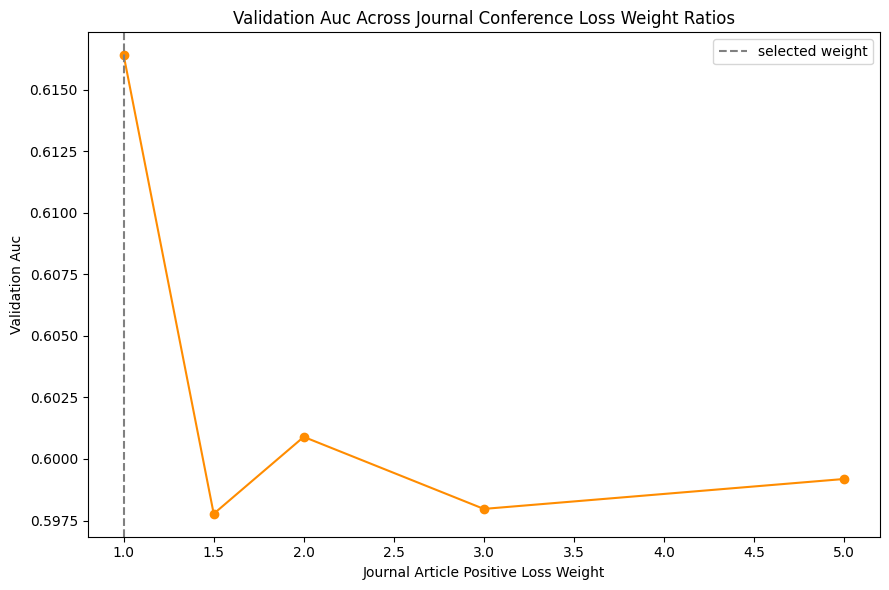

artifact registered output/viz/journal_conference_weight_ablation.png validation auc curve across journal versus conference loss weight ratio candidates


In [43]:
class RGCNLinkPredictor(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_relations):
        super().__init__()
        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.conv1 = RGCNConv(hidden_dim, hidden_dim, num_relations)
        self.conv2 = RGCNConv(hidden_dim, hidden_dim, num_relations)

    def forward(self, x, edge_index, edge_type):
        hidden = F.relu(self.input_proj(x))
        hidden = F.relu(self.conv1(hidden, edge_index, edge_type))
        hidden = self.conv2(hidden, edge_index, edge_type)
        return hidden

    def decode(self, z, pairs):
        idx_a = torch.tensor([p[0] for p in pairs], dtype=torch.long)
        idx_b = torch.tensor([p[1] for p in pairs], dtype=torch.long)
        return (z[idx_a] * z[idx_b]).sum(dim=-1)


def train_rgcn_model(weight_journal, weight_conference, epochs, hidden_dim=64, learning_rate=0.01):
    torch.manual_seed(RANDOM_SEED)
    model = RGCNLinkPredictor(node_feature_tensor.shape[1], hidden_dim, num_relations=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    positive_weights = torch.tensor(
        [
            weight_journal if "coauthored journal" in pair_relation_types[(a, b)] else weight_conference
            for a, b in train_positive_pairs_list
        ],
        dtype=torch.float32,
    )

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        z = model(node_feature_tensor, train_edge_index, train_edge_type)
        positive_logits = model.decode(z, train_positive_pairs_idx)
        negative_logits = model.decode(z, train_negatives_idx)
        positive_loss = F.binary_cross_entropy_with_logits(
            positive_logits, torch.ones_like(positive_logits), weight=positive_weights
        )
        negative_loss = F.binary_cross_entropy_with_logits(negative_logits, torch.zeros_like(negative_logits))
        total_loss = positive_loss + negative_loss
        total_loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        z = model(node_feature_tensor, train_edge_index, train_edge_type)
        val_pos_scores = model.decode(z, val_positive_pairs_idx).numpy()
        val_neg_scores = model.decode(z, val_negative_pairs_idx).numpy()
    val_auc = roc_auc_score(
        [1] * len(val_pos_scores) + [0] * len(val_neg_scores), list(val_pos_scores) + list(val_neg_scores)
    )
    return model, float(val_auc)


journal_weight_candidates = [1.0, 1.5, 2.0, 3.0, 5.0]
ablation_rows = []
for journal_weight in journal_weight_candidates:
    _, val_auc = train_rgcn_model(journal_weight, 1.0, epochs=150)
    ablation_rows.append({"journal_weight": journal_weight, "conference_weight": 1.0, "validation_auc": val_auc})
    print("journal weight", journal_weight, "validation auc", round(val_auc, 4))

ablation_df = pd.DataFrame(ablation_rows)
ablation_path = os.path.join(OUTPUT_ROOT, "journal_conference_weight_ablation.csv")
ablation_df.to_csv(ablation_path, index=False)
register_artifact(ablation_path, "ablation study of journal versus conference positive loss weight ratio measured by validation auc")

BEST_JOURNAL_WEIGHT = float(ablation_df.loc[ablation_df["validation_auc"].idxmax(), "journal_weight"])
print("selected best journal weight from ablation", BEST_JOURNAL_WEIGHT)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(ablation_df["journal_weight"], ablation_df["validation_auc"], marker="o", color="darkorange")
ax.axvline(BEST_JOURNAL_WEIGHT, color="gray", linestyle="dashed", label="selected weight")
ax.set_xlabel("Journal Article Positive Loss Weight")
ax.set_ylabel("Validation Auc")
ax.set_title("Validation Auc Across Journal Conference Loss Weight Ratios")
ax.legend()
plt.tight_layout()
ablation_viz_path = os.path.join(OUTPUT_VIZ, "journal_conference_weight_ablation.png")
plt.savefig(ablation_viz_path, dpi=150)
plt.show()
register_artifact(ablation_viz_path, "validation auc curve across journal versus conference loss weight ratio candidates")

### Variational Graph Autoencoder With Graphsage Encoder
Empat model learned dilatih dan dibandingkan dengan dua baseline non-learned (jaccard, adamic adar) menggunakan node/entity feature historis, agar performa setiap model dapat dinilai secara adil pada task yang sama.

vgae final training loss 1.2302289009094238


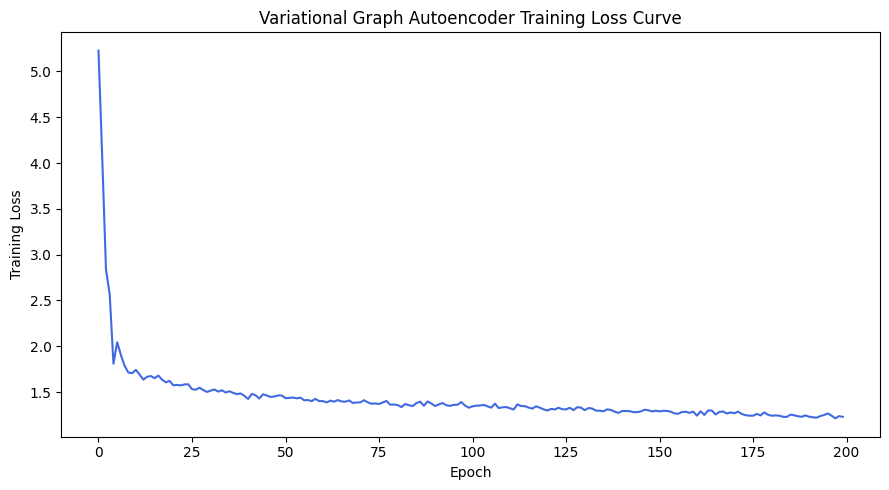

artifact registered output/viz/vgae_training_loss_curve.png training loss curve for the variational graph autoencoder model
artifact registered output/models/vgae_graphsage_model.pt trained variational graph autoencoder with graphsage encoder state dict


In [44]:
class SageVariationalEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv_mu = SAGEConv(hidden_dim, out_dim)
        self.conv_logstd = SAGEConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        hidden = F.relu(self.conv1(x, edge_index))
        return self.conv_mu(hidden, edge_index), self.conv_logstd(hidden, edge_index)


torch.manual_seed(RANDOM_SEED)
vgae_model = VGAE(SageVariationalEncoder(node_feature_tensor.shape[1], 64, 32))
vgae_optimizer = torch.optim.Adam(vgae_model.parameters(), lr=0.01)

vgae_positive_weights = torch.tensor(
    [
        BEST_JOURNAL_WEIGHT if "coauthored journal" in pair_relation_types[(a, b)] else 1.0
        for a, b in train_positive_pairs_list
    ],
    dtype=torch.float32,
)

vgae_train_edge_index_undirected = train_edge_index

vgae_loss_history = []
for epoch in range(200):
    vgae_model.train()
    vgae_optimizer.zero_grad()
    z = vgae_model.encode(node_feature_tensor, vgae_train_edge_index_undirected)
    positive_logits = vgae_model.decoder(z, torch.tensor(train_positive_pairs_idx).t(), sigmoid=False)
    negative_logits = vgae_model.decoder(z, torch.tensor(train_negatives_idx).t(), sigmoid=False)
    positive_loss = F.binary_cross_entropy_with_logits(
        positive_logits, torch.ones_like(positive_logits), weight=vgae_positive_weights
    )
    negative_loss = F.binary_cross_entropy_with_logits(negative_logits, torch.zeros_like(negative_logits))
    kl_term = (1.0 / node_feature_tensor.shape[0]) * vgae_model.kl_loss()
    loss = positive_loss + negative_loss + kl_term
    loss.backward()
    vgae_optimizer.step()
    vgae_loss_history.append(float(loss.item()))

print("vgae final training loss", vgae_loss_history[-1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(vgae_loss_history, color="royalblue")
ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Variational Graph Autoencoder Training Loss Curve")
plt.tight_layout()
vgae_loss_viz_path = os.path.join(OUTPUT_VIZ, "vgae_training_loss_curve.png")
plt.savefig(vgae_loss_viz_path, dpi=150)
plt.show()
register_artifact(vgae_loss_viz_path, "training loss curve for the variational graph autoencoder model")

vgae_model_path = os.path.join(OUTPUT_MODELS, "vgae_graphsage_model.pt")
torch.save(vgae_model.state_dict(), vgae_model_path)
register_artifact(vgae_model_path, "trained variational graph autoencoder with graphsage encoder state dict")

### Relational Graph Convolutional Network Final Training

In [45]:
rgcn_model, rgcn_val_auc = train_rgcn_model(BEST_JOURNAL_WEIGHT, 1.0, epochs=250)
print("rgcn final validation auc using selected weight ratio", round(rgcn_val_auc, 4))

rgcn_model_path = os.path.join(OUTPUT_MODELS, "rgcn_model.pt")
torch.save(rgcn_model.state_dict(), rgcn_model_path)
register_artifact(rgcn_model_path, "trained relational graph convolutional network state dict")

rgcn final validation auc using selected weight ratio 0.6209
artifact registered output/models/rgcn_model.pt trained relational graph convolutional network state dict


### Knowledge Graph Embedding Entity And Relation Indexing

In [46]:
kge_observed_entities = pd.unique(pd.concat([kge_train_triples_df["head"], kge_train_triples_df["tail"]], ignore_index=True))
kge_observed_entities_set = set(kge_observed_entities)
kge_missing_author_entities = [f"author::{author_id}" for author_id in all_author_ids_sorted if f"author::{author_id}" not in kge_observed_entities_set]
kge_all_entities = np.concatenate([kge_observed_entities, np.array(kge_missing_author_entities, dtype=object)])
kge_entity_to_index = {entity_name: idx for idx, entity_name in enumerate(kge_all_entities)}
kge_relation_to_index = {relation_name: idx for idx, relation_name in enumerate(sorted(kge_train_triples_df["relation"].unique()))}
kge_entity_type_id = torch.tensor([
    {"author": 0, "paper": 1, "topic": 2, "journal": 3}[entity_type(name)] for name in kge_all_entities
])
kge_type_pools = {
    type_id: (kge_entity_type_id == type_id).nonzero(as_tuple=True)[0]
    for type_id in kge_entity_type_id.unique().tolist()
}
kge_head_idx = torch.tensor([kge_entity_to_index[h] for h in kge_train_triples_df["head"]], dtype=torch.long)
kge_tail_idx = torch.tensor([kge_entity_to_index[t] for t in kge_train_triples_df["tail"]], dtype=torch.long)
kge_rel_idx = torch.tensor([kge_relation_to_index[r] for r in kge_train_triples_df["relation"]], dtype=torch.long)
kge_triple_weights = torch.tensor(
    [BEST_JOURNAL_WEIGHT if r == "coauthored journal" else 1.0 for r in kge_train_triples_df["relation"]],
    dtype=torch.float32,
)
print("kge entity count", len(kge_all_entities))
print("kge author entities added without any historical triple", len(kge_missing_author_entities))
print("kge relation count", len(kge_relation_to_index))
print("kge triple count", kge_head_idx.shape[0])

class TypeConstrainedNegativeSamplingMixin:
    def random_sample(self, head_index, rel_type, tail_index):
        n_triples_batch = head_index.numel()
        n_head_corrupt = n_triples_batch // 2
        new_head_index = head_index.clone()
        new_tail_index = tail_index.clone()
        for position in range(n_head_corrupt):
            entity_type_id_value = int(kge_entity_type_id[head_index[position]])
            pool = kge_type_pools[entity_type_id_value]
            new_head_index[position] = pool[torch.randint(0, len(pool), (1,))]
        for position in range(n_head_corrupt, n_triples_batch):
            entity_type_id_value = int(kge_entity_type_id[tail_index[position]])
            pool = kge_type_pools[entity_type_id_value]
            new_tail_index[position] = pool[torch.randint(0, len(pool), (1,))]
        return new_head_index, rel_type, new_tail_index


class TypeConstrainedRotatE(TypeConstrainedNegativeSamplingMixin, RotatE):
    pass


class TypeConstrainedComplEx(TypeConstrainedNegativeSamplingMixin, ComplEx):
    pass

kge entity count 6899
kge author entities added without any historical triple 2
kge relation count 5
kge triple count 17779


### Knowledge Graph Embedding Model Training

rotate final average epoch loss 0.45378925071822274
complex final average epoch loss 0.07874733313090271


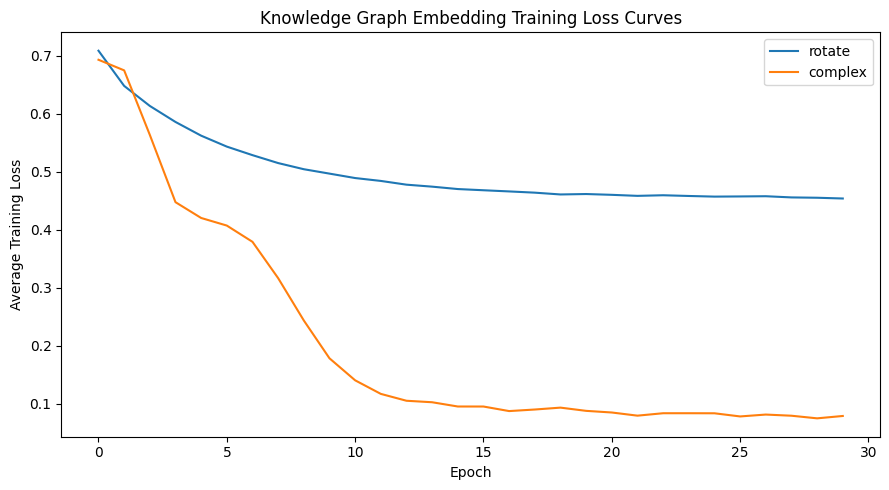

artifact registered output/viz/kge_training_loss_curves.png training loss curves for rotate and complex knowledge graph embedding models
artifact registered output/models/rotate_model.pt trained rotate knowledge graph embedding model state dict
artifact registered output/models/complex_model.pt trained complex knowledge graph embedding model state dict


In [47]:
def train_kge_model(model_class, hidden_channels, epochs, batch_size, learning_rate):
    torch.manual_seed(RANDOM_SEED)
    model = model_class(num_nodes=len(kge_all_entities), num_relations=len(kge_relation_to_index), hidden_channels=hidden_channels)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    n_triples_total = kge_head_idx.shape[0]
    loss_history = []
    for epoch in range(epochs):
        permutation = torch.randperm(n_triples_total)
        epoch_loss = 0.0
        n_batches = 0
        for start in range(0, n_triples_total, batch_size):
            batch_idx = permutation[start:start + batch_size]
            batch_head = kge_head_idx[batch_idx]
            batch_rel = kge_rel_idx[batch_idx]
            batch_tail = kge_tail_idx[batch_idx]
            batch_weight = kge_triple_weights[batch_idx]

            optimizer.zero_grad()
            positive_score = model(batch_head, batch_rel, batch_tail)
            negative_head, negative_rel, negative_tail = model.random_sample(batch_head, batch_rel, batch_tail)
            negative_score = model(negative_head, negative_rel, negative_tail)

            all_scores = torch.cat([positive_score, negative_score])
            all_targets = torch.cat([torch.ones_like(positive_score), torch.zeros_like(negative_score)])
            all_weights = torch.cat([batch_weight, torch.ones_like(negative_score)])

            loss = F.binary_cross_entropy_with_logits(all_scores, all_targets, weight=all_weights)
            loss.backward()
            optimizer.step()
            epoch_loss += float(loss.item())
            n_batches += 1
        loss_history.append(epoch_loss / n_batches)
    return model, loss_history


rotate_model, rotate_loss_history = train_kge_model(TypeConstrainedRotatE, hidden_channels=64, epochs=30, batch_size=1024, learning_rate=0.01)
print("rotate final average epoch loss", rotate_loss_history[-1])

complex_model, complex_loss_history = train_kge_model(TypeConstrainedComplEx, hidden_channels=64, epochs=30, batch_size=1024, learning_rate=0.01)
print("complex final average epoch loss", complex_loss_history[-1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rotate_loss_history, label="rotate")
ax.plot(complex_loss_history, label="complex")
ax.set_xlabel("Epoch")
ax.set_ylabel("Average Training Loss")
ax.set_title("Knowledge Graph Embedding Training Loss Curves")
ax.legend()
plt.tight_layout()
kge_loss_viz_path = os.path.join(OUTPUT_VIZ, "kge_training_loss_curves.png")
plt.savefig(kge_loss_viz_path, dpi=150)
plt.show()
register_artifact(kge_loss_viz_path, "training loss curves for rotate and complex knowledge graph embedding models")

rotate_model_path = os.path.join(OUTPUT_MODELS, "rotate_model.pt")
complex_model_path = os.path.join(OUTPUT_MODELS, "complex_model.pt")
torch.save(rotate_model.state_dict(), rotate_model_path)
torch.save(complex_model.state_dict(), complex_model_path)
register_artifact(rotate_model_path, "trained rotate knowledge graph embedding model state dict")
register_artifact(complex_model_path, "trained complex knowledge graph embedding model state dict")

### Model Evaluation On Test Split
Setiap model dievaluasi dengan AUC, average precision, hits@10, dan MRR pada test set, lalu performanya dipecah lagi menjadi subset cold start vs bukan cold start untuk mengonfirmasi apakah kesulitan prediksi berasal dari keterbatasan struktural data atau kelemahan model itu sendiri.

In [48]:
def score_vgae_pairs(pairs_idx):
    vgae_model.eval()
    with torch.no_grad():
        z = vgae_model.encode(node_feature_tensor, train_edge_index)
        edge_tensor = torch.tensor(pairs_idx, dtype=torch.long).t()
        scores = vgae_model.decoder(z, edge_tensor, sigmoid=False)
    return scores.numpy().tolist()

def score_rgcn_pairs(pairs_idx):
    rgcn_model.eval()
    with torch.no_grad():
        z = rgcn_model(node_feature_tensor, train_edge_index, train_edge_type)
        scores = rgcn_model.decode(z, pairs_idx)
    return scores.numpy().tolist()


journal_relation_id = kge_relation_to_index["coauthored journal"]
conference_relation_id = kge_relation_to_index["coauthored conference"]


def score_kge_pairs(model, pairs_author_ids):
    model.eval()
    head_idx = torch.tensor([kge_entity_to_index[f"author::{a}"] for a, b in pairs_author_ids], dtype=torch.long)
    tail_idx = torch.tensor([kge_entity_to_index[f"author::{b}"] for a, b in pairs_author_ids], dtype=torch.long)
    with torch.no_grad():
        journal_scores = model(head_idx, torch.full_like(head_idx, journal_relation_id), tail_idx)
        conference_scores = model(head_idx, torch.full_like(head_idx, conference_relation_id), tail_idx)
        combined_scores = torch.maximum(journal_scores, conference_scores)
    return combined_scores.numpy().tolist()

learned_model_results = []
for model_name, score_function, needs_string_ids in [
    ("variational graph autoencoder graphsage", score_vgae_pairs, False),
    ("relational graph convolutional network", score_rgcn_pairs, False),
    ("rotate knowledge graph embedding", lambda pairs: score_kge_pairs(rotate_model, pairs), True),
    ("complex knowledge graph embedding", lambda pairs: score_kge_pairs(complex_model, pairs), True),
]:
    if needs_string_ids:
        test_pos_scores = score_function(test_eval_positive_pairs)
        test_neg_scores = score_function(test_eval_negative_pairs)
    else:
        test_pos_scores = score_function(test_positive_pairs_idx)
        test_neg_scores = score_function(test_negative_pairs_idx)
    metrics = evaluate_link_prediction(test_pos_scores, test_neg_scores)
    metrics["model"] = model_name
    learned_model_results.append(metrics)
    print(model_name, metrics)

learned_model_results_df = pd.DataFrame(learned_model_results)

variational graph autoencoder graphsage {'auc': np.float64(0.6480512494498508), 'average_precision': np.float64(0.47833950393764224), 'hits_at_10': 0.09090909090909091, 'mean_reciprocal_rank': 0.04132699138403725, 'model': 'variational graph autoencoder graphsage'}
relational graph convolutional network {'auc': np.float64(0.6517678126069735), 'average_precision': np.float64(0.4570946209401437), 'hits_at_10': 0.07692307692307693, 'mean_reciprocal_rank': 0.030732859453877066, 'model': 'relational graph convolutional network'}
rotate knowledge graph embedding {'auc': np.float64(0.6770746735781701), 'average_precision': np.float64(0.5044182906964648), 'hits_at_10': 0.11188811188811189, 'mean_reciprocal_rank': 0.038101013399413235, 'model': 'rotate knowledge graph embedding'}
complex knowledge graph embedding {'auc': np.float64(0.5769964301432833), 'average_precision': np.float64(0.41718854749658196), 'hits_at_10': 0.09090909090909091, 'mean_reciprocal_rank': 0.03830734879771348, 'model': '

### Model Comparison Table And Visualization

                                     model       auc  average_precision  \
0                 common neighbors jaccard  0.636706           0.457872   
1                              adamic adar  0.629701           0.447731   
2  variational graph autoencoder graphsage  0.648051           0.478340   
3   relational graph convolutional network  0.651768           0.457095   
4         rotate knowledge graph embedding  0.677075           0.504418   
5        complex knowledge graph embedding  0.576996           0.417189   

   hits_at_10  mean_reciprocal_rank  
0    0.076923              0.037831  
1    0.055944              0.043764  
2    0.090909              0.041327  
3    0.076923              0.030733  
4    0.111888              0.038101  
5    0.090909              0.038307  
artifact registered output/model_comparison.csv comparison table of all link prediction models on test split metrics


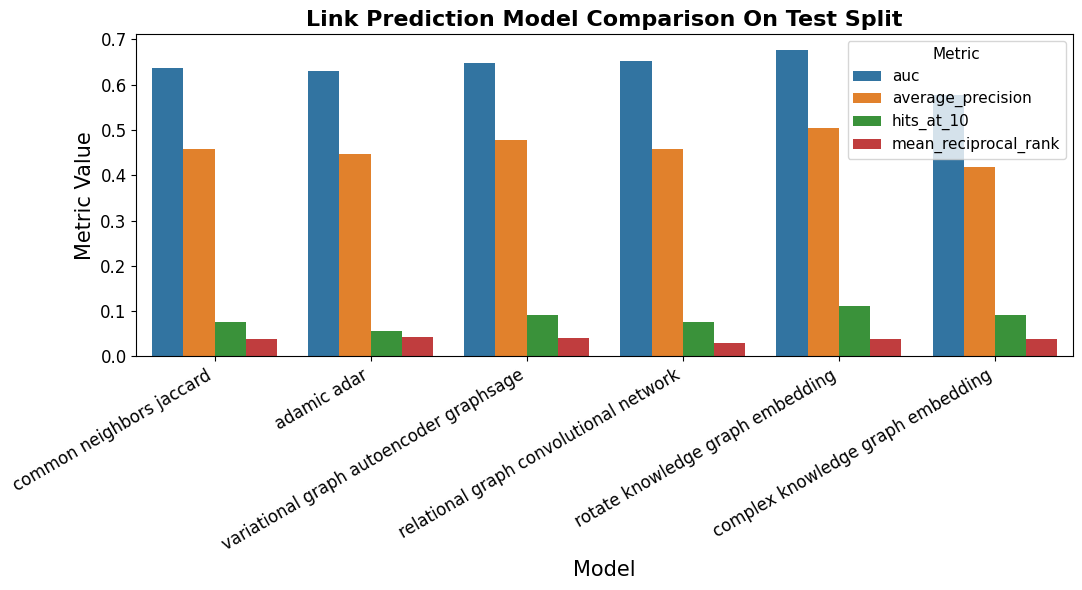

artifact registered output/viz/model_comparison_bar_chart.png bar chart comparing all link prediction models across evaluation metrics


In [49]:
model_comparison_df = pd.concat([baseline_results_df, learned_model_results_df], ignore_index=True)
model_comparison_df = model_comparison_df[["model", "auc", "average_precision", "hits_at_10", "mean_reciprocal_rank"]]
print(model_comparison_df)

model_comparison_path = os.path.join(OUTPUT_ROOT, "model_comparison.csv")
model_comparison_df.to_csv(model_comparison_path, index=False)
register_artifact(model_comparison_path, "comparison table of all link prediction models on test split metrics")

fig, ax = plt.subplots(figsize=(11, 6))
plot_metrics_df = model_comparison_df.melt(id_vars="model", var_name="metric", value_name="value")
sns.barplot(data=plot_metrics_df, x="model", y="value", hue="metric", ax=ax)
ax.set_title("Link Prediction Model Comparison On Test Split", fontsize=16, fontweight="bold")
ax.set_xlabel("Model", fontsize=15)
ax.set_ylabel("Metric Value", fontsize=15)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
plt.xticks(rotation=30, ha="right")

legend = ax.get_legend()
legend.set_title("Metric")
plt.setp(legend.get_title(), fontsize=11)
plt.setp(legend.get_texts(), fontsize=11)

plt.tight_layout()
model_comparison_viz_path = os.path.join(OUTPUT_VIZ, "model_comparison_bar_chart.png")
plt.savefig(model_comparison_viz_path, dpi=300, bbox_inches="tight")
plt.show()
register_artifact(model_comparison_viz_path, "bar chart comparing all link prediction models across evaluation metrics")

### Cold Start Versus Non Cold Start Breakdown
Metrik evaluasi pada test split dipecah menjadi dua subset, cold start dan non-cold start, untuk setiap model.

In [50]:
test_pair_cold_start_lookup = dict(
    zip(zip(test_positive_pairs_df["author_a"], test_positive_pairs_df["author_b"]), test_positive_pairs_df["is_cold_start"])
)

def split_by_cold_start(pairs_author_ids):
    cold_start_pairs = [p for p in pairs_author_ids if test_pair_cold_start_lookup.get(p, not has_common_neighbor(training_graph, p[0], p[1]))]
    non_cold_start_pairs = [p for p in pairs_author_ids if p not in cold_start_pairs]
    return cold_start_pairs, non_cold_start_pairs


cold_start_test_positive, non_cold_start_test_positive = split_by_cold_start(test_eval_positive_pairs)
cold_start_test_negative, non_cold_start_test_negative = split_by_cold_start(test_eval_negative_pairs)

print("cold start positive test pairs", len(cold_start_test_positive))
print("non cold start positive test pairs", len(non_cold_start_test_positive))

def to_idx_pairs(pairs_author_ids):
    return [(author_id_to_index[a], author_id_to_index[b]) for a, b in pairs_author_ids]


cold_start_breakdown_rows = []
for model_name, score_function, needs_string_ids in [
    ("common neighbors jaccard", lambda pairs: score_pairs_jaccard(training_graph, pairs), True),
    ("adamic adar", lambda pairs: score_pairs_adamic_adar(training_graph, pairs), True),
    ("variational graph autoencoder graphsage", lambda pairs: score_vgae_pairs(to_idx_pairs(pairs)), True),
    ("relational graph convolutional network", lambda pairs: score_rgcn_pairs(to_idx_pairs(pairs)), True),
    ("rotate knowledge graph embedding", lambda pairs: score_kge_pairs(rotate_model, pairs), True),
    ("complex knowledge graph embedding", lambda pairs: score_kge_pairs(complex_model, pairs), True),
]:
    for subset_name, positive_subset, negative_subset in [
        ("cold start", cold_start_test_positive, cold_start_test_negative),
        ("non cold start", non_cold_start_test_positive, non_cold_start_test_negative),
    ]:
        if len(positive_subset) == 0 or len(negative_subset) == 0:
            continue
        positive_scores = score_function(positive_subset)
        negative_scores = score_function(negative_subset)
        metrics = evaluate_link_prediction(positive_scores, negative_scores)
        metrics["model"] = model_name
        metrics["subset"] = subset_name
        metrics["n_positive"] = len(positive_subset)
        metrics["n_negative"] = len(negative_subset)
        cold_start_breakdown_rows.append(metrics)

cold_start_breakdown_df = pd.DataFrame(cold_start_breakdown_rows)
print(cold_start_breakdown_df)

cold_start_breakdown_path = os.path.join(OUTPUT_ROOT, "cold_start_breakdown.csv")
cold_start_breakdown_df.to_csv(cold_start_breakdown_path, index=False)
register_artifact(cold_start_breakdown_path, "per model evaluation metrics broken down by cold start versus non cold start test subset")

cold start positive test pairs 42
non cold start positive test pairs 101
         auc  average_precision  hits_at_10  mean_reciprocal_rank  \
0   0.500000           0.238636    0.000000              0.007407   
1   0.631318           0.509661    0.108911              0.052114   
2   0.500000           0.238636    0.000000              0.007407   
3   0.612656           0.495302    0.079208              0.060514   
4   0.476013           0.247510    0.047619              0.044765   
5   0.699844           0.572341    0.158416              0.060458   
6   0.576226           0.275823    0.047619              0.031452   
7   0.678609           0.572732    0.168317              0.074363   
8   0.611230           0.372693    0.214286              0.091822   
9   0.666232           0.543967    0.158416              0.051118   
10  0.549218           0.283653    0.047619              0.050765   
11  0.527944           0.458126    0.118812              0.053023   

                             

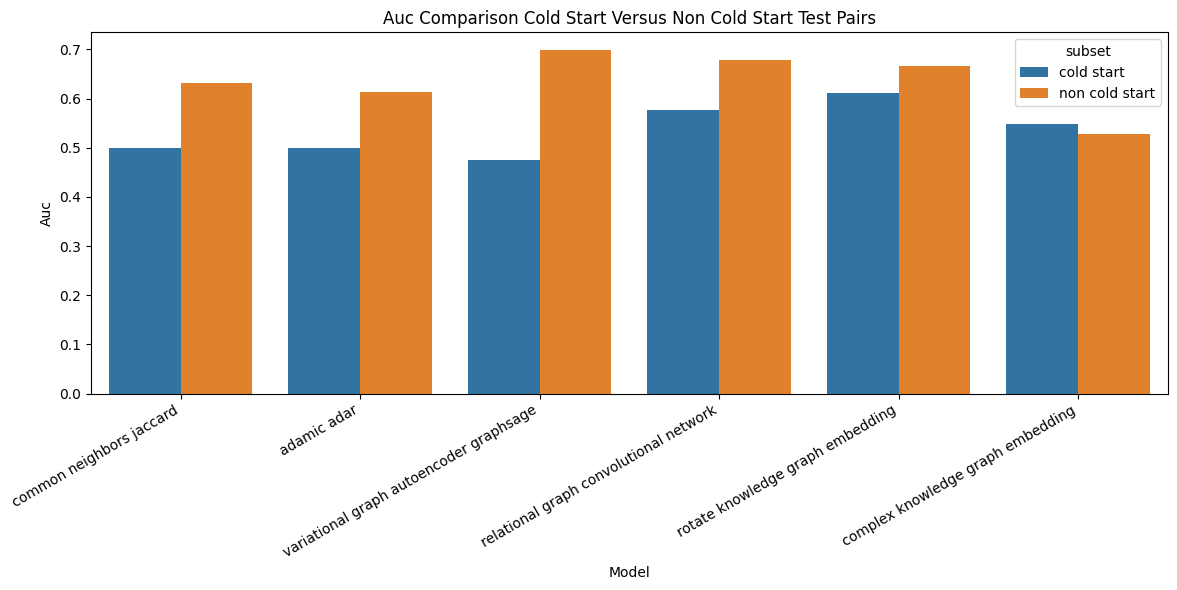

artifact registered output/viz/cold_start_breakdown_auc.png auc comparison between cold start and non cold start test subsets across all models


In [51]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=cold_start_breakdown_df, x="model", y="auc", hue="subset", ax=ax)
ax.set_title("Auc Comparison Cold Start Versus Non Cold Start Test Pairs")
ax.set_xlabel("Model")
ax.set_ylabel("Auc")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
cold_start_viz_path = os.path.join(OUTPUT_VIZ, "cold_start_breakdown_auc.png")
plt.savefig(cold_start_viz_path, dpi=150)
plt.show()
register_artifact(cold_start_viz_path, "auc comparison between cold start and non cold start test subsets across all models")

### Result and Interpretation

#### Top 3 Models

In [52]:
ranking_metric_columns = ["auc", "average_precision", "hits_at_10", "mean_reciprocal_rank"]
model_comparison_ranked_df = model_comparison_df.copy()
for metric_column in ranking_metric_columns:
    model_comparison_ranked_df[metric_column + "_rank"] = model_comparison_ranked_df[metric_column].rank(ascending=False)
model_comparison_ranked_df["average_rank"] = model_comparison_ranked_df[[c + "_rank" for c in ranking_metric_columns]].mean(axis=1)
top3_models_df = model_comparison_ranked_df.sort_values("average_rank").head(3).reset_index(drop=True)

print("top 3 best models based on average rank across auc, average precision, hits@10, and mrr")
print(top3_models_df[["model"] + ranking_metric_columns + ["average_rank"]])

for position, row in top3_models_df.iterrows():
    print(
        "rank", position + 1, "-", row["model"],
        "| auc", round(row["auc"], 4),
        "| average precision", round(row["average_precision"], 4),
        "| hits@10", round(row["hits_at_10"], 4),
        "| mrr", round(row["mean_reciprocal_rank"], 4),
    )

top3_models_path = os.path.join(OUTPUT_ROOT, "top3_link_prediction_models.csv")
top3_models_df[["model"] + ranking_metric_columns + ["average_rank"]].to_csv(top3_models_path, index=False)
register_artifact(top3_models_path, "top 3 link prediction models ranked by average rank across auc, average precision, hits at 10, and mean reciprocal rank")

top 3 best models based on average rank across auc, average precision, hits@10, and mrr
                                     model       auc  average_precision  \
0         rotate knowledge graph embedding  0.677075           0.504418   
1  variational graph autoencoder graphsage  0.648051           0.478340   
2   relational graph convolutional network  0.651768           0.457095   

   hits_at_10  mean_reciprocal_rank  average_rank  
0    0.111888              0.038101         1.750  
1    0.090909              0.041327         2.375  
2    0.076923              0.030733         4.125  
rank 1 - rotate knowledge graph embedding | auc 0.6771 | average precision 0.5044 | hits@10 0.1119 | mrr 0.0381
rank 2 - variational graph autoencoder graphsage | auc 0.6481 | average precision 0.4783 | hits@10 0.0909 | mrr 0.0413
rank 3 - relational graph convolutional network | auc 0.6518 | average precision 0.4571 | hits@10 0.0769 | mrr 0.0307
artifact registered output/top3_link_prediction_models

#### Future Collaboration Demo
Menggunakan model dengan performa terbaik dari perbandingan sebelumnya, bagian ini memprediksi pasangan dosen yang belum pernah berkolaborasi sama sekali namun punya peluang paling tinggi untuk berkolaborasi ke depannya. Perlu dicatat, fitur node yang dipakai model neural berasal dari embedding historis sampai tahun cutoff, jadi hasil prediksi ini sifatnya adalah proyeksi dari pola kolaborasi yang sudah dipelajari model terhadap pasangan dosen yang benar-benar belum pernah bekerja sama.

In [53]:
best_model_name = top3_models_df.iloc[0]["model"]
print("best model used for the future prediction example", best_model_name)
print("note, neural model node features use historical embedding up to the cutoff year, so predictions reflect a projection from patterns the model already learned onto author pairs that have never collaborated at all")

future_candidate_pairs = [
    (author_a, author_b)
    for author_a, author_b in itertools.combinations(sorted(coauthor_projection_graph.nodes()), 2)
    if not coauthor_projection_graph.has_edge(author_a, author_b)
]
print("number of candidate author pairs who have never collaborated", len(future_candidate_pairs))

def score_future_pairs_with_model(model_name, pairs_author_ids):
    if model_name == "common neighbors jaccard":
        return score_pairs_jaccard(coauthor_projection_graph, pairs_author_ids)
    if model_name == "adamic adar":
        return score_pairs_adamic_adar(coauthor_projection_graph, pairs_author_ids)
    if model_name == "variational graph autoencoder graphsage":
        return score_vgae_pairs(to_idx_pairs(pairs_author_ids))
    if model_name == "relational graph convolutional network":
        return score_rgcn_pairs(to_idx_pairs(pairs_author_ids))
    if model_name == "rotate knowledge graph embedding":
        return score_kge_pairs(rotate_model, pairs_author_ids)
    if model_name == "complex knowledge graph embedding":
        return score_kge_pairs(complex_model, pairs_author_ids)
    raise ValueError("unknown model name " + model_name)

future_pair_scores = score_future_pairs_with_model(best_model_name, future_candidate_pairs)

future_prediction_rows = []
for (author_a, author_b), score in zip(future_candidate_pairs, future_pair_scores):
    future_prediction_rows.append(
        {
            "author_a_id": author_a,
            "author_b_id": author_b,
            "author_a_name": canonical_name_map.get(author_a, author_a),
            "author_b_name": canonical_name_map.get(author_b, author_b),
            "predicted_score": float(score),
        }
    )
future_prediction_df = pd.DataFrame(future_prediction_rows).sort_values("predicted_score", ascending=False).reset_index(drop=True)
top_future_predictions_df = future_prediction_df.head(10)
print("top 10 author pairs with the highest predicted collaboration likelihood going forward according to", best_model_name)
print(top_future_predictions_df[["author_a_name", "author_b_name", "predicted_score"]])

future_prediction_path = os.path.join(OUTPUT_ROOT, "future_collaboration_predictions.csv")
future_prediction_df.to_csv(future_prediction_path, index=False)
register_artifact(future_prediction_path, "predicted likelihood scores for all author pairs that have never collaborated, generated by the best performing link prediction model, sorted from most to least likely")

best model used for the future prediction example rotate knowledge graph embedding
note, neural model node features use historical embedding up to the cutoff year, so predictions reflect a projection from patterns the model already learned onto author pairs that have never collaborated at all
number of candidate author pairs who have never collaborated 6721
top 10 author pairs with the highest predicted collaboration likelihood going forward according to rotate knowledge graph embedding
              author_a_name            author_b_name  predicted_score
0                  Rusijono                  Mustaji         0.679795
1      Aries Dwi Indriyanti      Ardhini Warih Utami         0.611676
2        Unit Three Kartini  Aditya Chandra Hermawan         0.566938
3           Miftahur Rohman   Parama Diptya Widayaka         0.530261
4  Hujjatullah Fazlurrahman      Nadia Nur Thahirrah         0.526631
5             Agus Prihanto          I Made Suartana         0.508767
6            Reza 

## Expert Retrieval Module
Mengembalikan lima penulis paling relevan untuk sebuah query topik bebas teks, dengan hasil yang benar-benar relevan secara topikal, tidak hanya penulis paling produktif.

### Structural Author Embedding From Trained Graph Neural Network
Bagian ini mengambil "posisi" setiap dosen di dalam jaringan kolaborasi menggunakan model RGCN yang sudah dilatih sebelumnya. Embedding yang dipakai adalah versi penuh (seluruh riwayat publikasi), bukan versi historis yang dibatasi tahun cutoff, karena expert retrieval tidak butuh batasan waktu seperti pada link prediction.

In [54]:
full_pair_relation_types = {}
for _, edge_row in all_coauthor_edges_df.iterrows():
    key = (edge_row["author_a"], edge_row["author_b"])
    full_pair_relation_types.setdefault(key, set()).add(edge_row["relation"])

full_edge_index_list = []
full_edge_type_list = []
for (author_a, author_b), relation_set in full_pair_relation_types.items():
    idx_a = author_id_to_index[author_a]
    idx_b = author_id_to_index[author_b]
    relation_code = 0 if "coauthored journal" in relation_set else 1
    full_edge_index_list.append([idx_a, idx_b])
    full_edge_type_list.append(relation_code)
    full_edge_index_list.append([idx_b, idx_a])
    full_edge_type_list.append(relation_code)

full_edge_index = torch.tensor(full_edge_index_list, dtype=torch.long).t().contiguous()
full_edge_type = torch.tensor(full_edge_type_list, dtype=torch.long)

author_content_embedding_full_tensor = torch.tensor(
    author_content_embedding_full.set_index("author_id").reindex(all_author_ids_sorted)[paper_embedding_columns].fillna(0.0).values,
    dtype=torch.float32,
)
print("full period node feature tensor shape", tuple(author_content_embedding_full_tensor.shape))
print("full period graph edge index shape", tuple(full_edge_index.shape))

rgcn_model.eval()
with torch.no_grad():
    author_structural_embedding = rgcn_model(author_content_embedding_full_tensor, full_edge_index, full_edge_type).numpy()
print("structural author embedding shape used for expert retrieval", author_structural_embedding.shape)
author_structural_embedding_lookup = dict(zip(all_author_ids_sorted, author_structural_embedding))

full period node feature tensor shape (126, 384)
full period graph edge index shape (2, 2292)
structural author embedding shape used for expert retrieval (126, 64)


### Query Encoding And Topic Expansion
Query dari pengguna (misalnya "graph neural network") diubah menjadi vektor embedding memakai model yang sama dengan yang dipakai untuk paper. Vektor ini lalu diperluas (expanded) dengan mencampurkan centroid topik terdekat, tujuannya supaya pencarian topik jadi lebih luas cakupannya. Selain itu, ditambahkan juga pencarian langsung ke paper-paper yang paling mirip secara embedding, tanpa bergantung pada hasil clustering topik. Ini penting untuk topik yang jarang atau spesifik (misalnya cuma ada 1 paper di seluruh dataset), karena topik seperti itu bisa "tertelan" ke dalam cluster besar yang tidak relevan kalau hanya mengandalkan clustering topik saja.

In [55]:
topic_ids_ordered_list = sorted(clean_papers_df.loc[clean_papers_df["topic_id"] != -1, "topic_id"].unique())
topic_centroid_rows = []
for topic_id in topic_ids_ordered_list:
    topic_papers_mask = clean_papers_df["topic_id"] == topic_id
    topic_centroid_rows.append(paper_embeddings[topic_papers_mask.values].mean(axis=0))
topic_centroid_matrix = np.stack(topic_centroid_rows)
print("topic centroid matrix shape", topic_centroid_matrix.shape)

topic_structural_centroid_rows = []
for topic_id in topic_ids_ordered_list:
    topic_author_ids = paper_topic_long_valid.loc[paper_topic_long_valid["topic_id"] == topic_id, "author_id"].unique()
    topic_author_vectors = np.stack([
        author_structural_embedding_lookup[author_id] for author_id in topic_author_ids if author_id in author_structural_embedding_lookup
    ])
    topic_structural_centroid_rows.append(topic_author_vectors.mean(axis=0))
topic_structural_centroid_matrix = np.stack(topic_structural_centroid_rows)
topic_id_to_position = {topic_id: position for position, topic_id in enumerate(topic_ids_ordered_list)}
print("topic structural centroid matrix shape", topic_structural_centroid_matrix.shape)

def cosine_similarity_matrix(vector, matrix):
    vector_norm = vector / (np.linalg.norm(vector) + 1e-12)
    matrix_norm = matrix / (np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12)
    return matrix_norm @ vector_norm

def encode_and_expand_query(query_text, n_expansion_topics=3, n_direct_papers=50):
    query_embedding = sentence_model.encode([query_text], convert_to_numpy=True)[0]
    topic_similarities = cosine_similarity_matrix(query_embedding, topic_centroid_matrix)
    top_topic_positions = np.argsort(topic_similarities)[::-1][:n_expansion_topics]
    top_topic_ids = [topic_ids_ordered_list[i] for i in top_topic_positions]

    expanded_embedding = query_embedding.astype(np.float64).copy()
    weight_accumulator = 1.0
    for position in top_topic_positions:
        similarity_weight = max(float(topic_similarities[position]), 0.0)
        expanded_embedding += similarity_weight * topic_centroid_matrix[position]
        weight_accumulator += similarity_weight
    expanded_embedding = expanded_embedding / weight_accumulator

    direct_paper_similarities = cosine_similarity_matrix(query_embedding, paper_embeddings)
    top_direct_positions = np.argsort(direct_paper_similarities)[::-1][:n_direct_papers]
    direct_match_paper_ids = clean_papers_df.iloc[top_direct_positions]["paper_id"].tolist()

    return query_embedding, expanded_embedding, top_topic_ids, topic_similarities, direct_match_paper_ids

print("query encoding and topic expansion function ready")

topic centroid matrix shape (59, 384)
topic structural centroid matrix shape (59, 64)
query encoding and topic expansion function ready


### Composite Relevance Scoring
Setiap dosen kandidat dinilai berdasarkan empat hal: seberapa mirip paper terbaiknya dengan query (cosine similarity), berapa banyak paper miliknya yang benar-benar relevan dengan query, seberapa aktif dia belakangan ini (faktor recency), dan seberapa dekat posisinya di graf kolaborasi dengan dosen-dosen lain di topik yang sama (graph proximity). Perhitungan jumlah paper relevan sekarang hanya menghitung paper yang memang lolos ambang batas kemiripan ke query, bukan seluruh paper penulis di cluster topik besarnya, supaya dosen yang produktif di topik lain tidak ikut terhitung sebagai "ahli" di topik yang sedang dicari. Judul paper yang menjadi dasar skor kemiripan tertinggi juga disimpan, supaya hasilnya bisa ditelusuri dan divalidasi secara manual.

In [56]:
current_max_year_observed = int(clean_papers_df["year"].max())
recency_gap_series = current_max_year_observed - author_feature_table.set_index("author_id")["last_active_year"]
positive_gap_values = recency_gap_series[recency_gap_series > 0]
recency_half_life = float(positive_gap_values.median()) if len(positive_gap_values) > 0 else 1.0
recency_decay_rate = math.log(2) / max(recency_half_life, 1.0)
print("recency half life years derived from data", recency_half_life)
print("recency decay rate derived from half life", recency_decay_rate)

author_last_active_lookup = author_feature_table.set_index("author_id")["last_active_year"].to_dict()
paper_doc_type_lookup = dict(zip(clean_papers_df["paper_id"], clean_papers_df["document_type_clean"]))

TOPICAL_RELEVANCE_CALIBRATION_SAMPLE_SIZE = 4000
calibration_rng = np.random.default_rng(RANDOM_SEED)
paper_topic_array = clean_papers_df["topic_id"].values
valid_topic_positions = np.where(paper_topic_array != -1)[0]
same_topic_pair_similarities = []
diff_topic_pair_similarities = []
for _ in range(TOPICAL_RELEVANCE_CALIBRATION_SAMPLE_SIZE):
    idx_a, idx_b = calibration_rng.choice(valid_topic_positions, size=2, replace=False)
    pair_similarity = cosine_similarity_matrix(paper_embeddings[idx_a], paper_embeddings[idx_b].reshape(1, -1))[0]
    if paper_topic_array[idx_a] == paper_topic_array[idx_b]:
        same_topic_pair_similarities.append(pair_similarity)
    else:
        diff_topic_pair_similarities.append(pair_similarity)
CONFIDENCE_HIGH_REFERENCE = float(np.median(same_topic_pair_similarities))
CONFIDENCE_LOW_REFERENCE = float(np.median(diff_topic_pair_similarities))
print("topical relevance high reference from intra topic paper similarity", CONFIDENCE_HIGH_REFERENCE)
print("topical relevance low reference used as retrieval floor", CONFIDENCE_LOW_REFERENCE)

def compute_candidate_scores(raw_query_embedding, top_topic_ids, direct_match_paper_ids):
    topic_candidate_rows = paper_topic_long_valid[paper_topic_long_valid["topic_id"].isin(top_topic_ids)][["author_id", "paper_id", "topic_id"]]
    direct_candidate_rows = paper_topic_long[paper_topic_long["paper_id"].isin(direct_match_paper_ids)][["author_id", "paper_id", "topic_id"]]
    combined_candidate_rows = pd.concat([topic_candidate_rows, direct_candidate_rows], ignore_index=True).drop_duplicates()
    candidate_author_ids = combined_candidate_rows["author_id"].unique().tolist()

    raw_component_rows = []
    for author_id in candidate_author_ids:
        author_candidate_papers = combined_candidate_rows[combined_candidate_rows["author_id"] == author_id]
        best_similarity = -1.0
        best_topic_id = None
        best_paper_id = None
        relevant_paper_ids = []
        for paper_id, topic_id in zip(author_candidate_papers["paper_id"], author_candidate_papers["topic_id"]):
            paper_vector = paper_id_to_embedding[paper_id]
            similarity = cosine_similarity_matrix(raw_query_embedding, paper_vector.reshape(1, -1))[0]
            if similarity >= CONFIDENCE_LOW_REFERENCE:
                relevant_paper_ids.append(paper_id)
            if similarity > best_similarity:
                best_similarity = similarity
                best_topic_id = topic_id
                best_paper_id = paper_id
        cosine_component = max(best_similarity, 0.0)
        if not relevant_paper_ids:
            relevant_paper_ids = [best_paper_id]
        topic_weighted_count = sum(
            BEST_JOURNAL_WEIGHT if paper_doc_type_lookup.get(paper_id) == "journal article" else 1.0
            for paper_id in set(relevant_paper_ids)
        )
        last_active_year = author_last_active_lookup.get(author_id, current_max_year_observed)
        recency_factor = math.exp(-recency_decay_rate * max(current_max_year_observed - last_active_year, 0))
        if author_id in author_structural_embedding_lookup and best_topic_id in topic_id_to_position:
            structural_vector = author_structural_embedding_lookup[author_id].reshape(1, -1)
            graph_proximity_component = max(
                float(cosine_similarity_matrix(topic_structural_centroid_matrix[topic_id_to_position[best_topic_id]], structural_vector)[0]),
                0.0,
            )
        else:
            graph_proximity_component = 0.0
        raw_component_rows.append(
            {
                "author_id": author_id,
                "best_topic_id": best_topic_id,
                "best_paper_id": best_paper_id,
                "n_papers_matched": len(set(relevant_paper_ids)),
                "cosine_similarity_component": cosine_component,
                "topic_weighted_publication_count_component": topic_weighted_count,
                "recency_factor_component": recency_factor,
                "graph_proximity_component": graph_proximity_component,
            }
        )
    return pd.DataFrame(raw_component_rows)
print("composite relevance scoring function ready")

recency half life years derived from data 1.0
recency decay rate derived from half life 0.6931471805599453
topical relevance high reference from intra topic paper similarity 0.45810091495513916
topical relevance low reference used as retrieval floor 0.264962762594223
composite relevance scoring function ready


### Expert Retrieval Function And Validation
Fungsi ini mengurutkan dosen kandidat berdasarkan cosine similarity ke query sebagai patokan utama, karena ini adalah sinyal relevansi yang paling langsung dan jujur. Komponen lain (posisi di graf kolaborasi, jumlah paper relevan, dan keaktifan terbaru) hanya dipakai sebagai pemecah seri kalau ada beberapa dosen dengan skor kemiripan yang sama persis, misalnya karena mereka menulis paper yang sama sebagai co-author. Hasil akhirnya juga menyertakan jumlah paper yang relevan dan judul paper spesifik yang menjadi dasar skornya, supaya setiap hasil pencarian bisa langsung dicek buktinya.

In [57]:
paper_id_to_title = dict(zip(clean_papers_df["paper_id"], clean_papers_df["title"]))

def retrieve_top_experts(query_text, top_k=10, n_expansion_topics=3, n_direct_papers=50, print_component_validation=False):
    query_embedding, expanded_embedding, top_topic_ids, topic_similarities, direct_match_paper_ids = encode_and_expand_query(
        query_text, n_expansion_topics=n_expansion_topics, n_direct_papers=n_direct_papers
    )
    candidate_scores_df = compute_candidate_scores(query_embedding, top_topic_ids, direct_match_paper_ids)
    if print_component_validation:
        print("query", query_text.upper())
        print("expanded query nearest topic ids", top_topic_ids)
        print("\ndirect match candidate papers", len(direct_match_paper_ids))
        print("\ncosine similarity component distribution")
        print(candidate_scores_df["cosine_similarity_component"].describe())
        print("\ntopic weighted publication count component distribution")
        print(candidate_scores_df["topic_weighted_publication_count_component"].describe())
        print("\nrecency factor component distribution")
        print(candidate_scores_df["recency_factor_component"].describe())
        print("\ngraph proximity component distribution")
        print(candidate_scores_df["graph_proximity_component"].describe())
    reliable_candidates_df = candidate_scores_df[candidate_scores_df["cosine_similarity_component"] >= CONFIDENCE_LOW_REFERENCE].copy()
    if print_component_validation:
        print("\ncandidates dropped for falling below topical relevance floor", candidate_scores_df.shape[0] - reliable_candidates_df.shape[0])
    if reliable_candidates_df.empty:
        print("\nno author found with sufficiently confident topical match for this query")
        return pd.DataFrame(columns=["author_id", "author_name", "best_topic_id", "confidence_score", "n_papers_matched", "matched_paper_title"])
    sort_columns = [
        "cosine_similarity_component",
        "graph_proximity_component",
        "topic_weighted_publication_count_component",
        "recency_factor_component",
    ]
    reliable_candidates_df = reliable_candidates_df.sort_values(sort_columns, ascending=False)
    reliable_candidates_df = reliable_candidates_df.merge(id_name_lookup_df, on="author_id", how="left")
    reliable_candidates_df["matched_paper_title"] = reliable_candidates_df["best_paper_id"].map(paper_id_to_title)
    reliable_candidates_df = reliable_candidates_df.rename(columns={"cosine_similarity_component": "confidence_score"})
    top_experts_df = reliable_candidates_df.head(top_k)
    top_experts_df = top_experts_df[
        ["author_id", "author_name", "best_topic_id", "confidence_score", "n_papers_matched", "matched_paper_title"]
    ].reset_index(drop=True)
    return top_experts_df

sample_query = "medis"
sample_result = retrieve_top_experts(sample_query, print_component_validation=True)
print(sample_result)

query MEDIS
expanded query nearest topic ids [np.int64(27), np.int64(55), np.int64(53)]

direct match candidate papers 50

cosine similarity component distribution
count    108.000000
mean       0.292069
std        0.095984
min        0.000000
25%        0.221395
50%        0.295226
75%        0.363021
max        0.571063
Name: cosine_similarity_component, dtype: float64

topic weighted publication count component distribution
count    108.000000
mean       1.527778
std        1.106128
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        7.000000
Name: topic_weighted_publication_count_component, dtype: float64

recency factor component distribution
count    108.000000
mean       0.424769
std        0.143939
min        0.125000
25%        0.250000
50%        0.500000
75%        0.500000
max        1.000000
Name: recency_factor_component, dtype: float64

graph proximity component distribution
count    108.000000
mean       0.289974
std        0.22964

### Expert Retrieval Demonstration Across Multiple Query Domains

In [58]:
demonstration_queries = [
    "machine learning",
    "cyber",
    "iot",
    "analisis sentimen",
    "graph neural network",
    "big data",
]

demonstration_rows = []
for query_text in demonstration_queries:
    top_experts_df = retrieve_top_experts(query_text, print_component_validation=False)
    for rank_position, expert_row in top_experts_df.iterrows():
        demonstration_rows.append(
            {
                "query": query_text,
                "rank": rank_position + 1,
                "author_id": expert_row["author_id"],
                "author_name": expert_row["author_name"],
                "confidence_score": expert_row["confidence_score"],
                "matched_topic_id": expert_row["best_topic_id"],
                "n_papers_matched": expert_row["n_papers_matched"],
                "matched_paper_title": expert_row["matched_paper_title"],
            }
        )
    print("\nquery", query_text.upper())
    print(top_experts_df)

demonstration_df = pd.DataFrame(demonstration_rows)
demonstration_path = os.path.join(OUTPUT_ROOT, "expert_retrieval_demonstration.csv")
demonstration_df.to_csv(demonstration_path, index=False)
register_artifact(demonstration_path, "demonstration of expert retrieval function across multiple topical query domains with matched paper title and match count as evidence")


query MACHINE LEARNING
      author_id            author_name  best_topic_id  confidence_score  \
0  Smb2eg8AAAAJ      Nanang Hoesen H A             39          0.728032   
1  Hl6bqU8AAAAJ   Rindu Puspita Wibawa             39          0.728032   
2  OffRzhoAAAAJ  Dwi Fatrianto Suyatno             28          0.705006   
3  t5f89iIAAAAJ   Andi Iwan Nurhidayat             28          0.705006   
4  7EQjv9wAAAAJ                Asmunin             28          0.705006   
5  fkxhjZ4AAAAJ            Ronggo Alit             45          0.704030   
6  LeRoniwAAAAJ          Farhanna Mari             45          0.704030   
7  N6RJilIAAAAJ          Anita Qoiriah             28          0.681148   
8  6MXDzBQAAAAJ           Lilik Anifah             28          0.668539   
9  hn5jrnAAAAAJ          Yuni Yamasari             25          0.659426   

   n_papers_matched                                matched_paper_title  
0                 3  machine learning on academic education: biblio...  
1   

## Final Artifact Summary

In [59]:
manifest_df = pd.DataFrame(ARTIFACT_MANIFEST)
manifest_path = os.path.join(OUTPUT_ROOT, "artifact_manifest.csv")
manifest_df.to_csv(manifest_path, index=False)
print("total artifacts registered", manifest_df.shape[0])
print(manifest_df)

total artifacts registered 48
                                                 path  \
0                        output/raw_shape_summary.csv   
1                        output/raw_dtype_summary.csv   
2                         output/raw_null_summary.csv   
3           output/viz/eda_overview_distributions.png   
4                 output/eda_distribution_summary.csv   
5     output/viz/top_authors_by_publication_count.png   
6         output/top_authors_by_publication_count.csv   
7                    output/missing_value_pattern.csv   
8           output/missing_value_by_document_type.csv   
9                  output/missing_value_by_source.csv   
10         output/ieee_keyword_count_distribution.csv   
11  output/viz/collaboration_edge_volume_and_cumul...   
12       output/collaboration_edge_volume_by_year.csv   
13                   output/author_id_name_lookup.csv   
14                            output/clean_papers.csv   
15                        output/paper_embeddings.csv   
1

## Package Output For Download

In [60]:
zip_output_path = "output.zip"
with zipfile.ZipFile(zip_output_path, "w", zipfile.ZIP_DEFLATED) as zip_file:
    for root, _, files in os.walk(OUTPUT_ROOT):
        for file_name in files:
            file_path = os.path.join(root, file_name)
            zip_file.write(file_path, os.path.relpath(file_path, OUTPUT_ROOT))

print("output archive created", zip_output_path)

try:
    from google.colab import files as colab_files

    colab_files.download(zip_output_path)
except ImportError:
    print("google colab download unavailable in this environment, archive saved locally at", zip_output_path)

output archive created output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>